In [4]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm

In [5]:
model_dir = Path("/Users/claudy/dev/work/tmp/models/0301_145629_base-grid_fault-weights_XYZ_loc")
z_ffp = Path("/Users/claudy/dev/work/tmp/site_params.csv")
map_data_ffp = Path("/Users/claudy/dev/work/code/qcore/qcore/data")

# model_dir = Path("/home/claudy/dev/work/data/nn_gmm/results/keep_runs/current/0301_145629_base-grid_fault-weights_XYZ_loc")
# z_ffp = Path("/home/claudy/dev/work/storage/data/nn_gmm/input_data/site_params/site_params.csv")
# map_data_ffp = Path("/home/claudy/dev/work/code/qcore/qcore/data")

In [6]:
# Load the data and compute the residual and squared residual
columns = ["site", "lat", "lon", "pSA_3.0", "pSA_3.0_est", "event", "vs30"]

data_df = nn_gmm.ResultDB.get_data_static(model_dir / "train_predictions.hdf5", columns=columns)
data_df["res"] = data_df["pSA_3.0"] - data_df["pSA_3.0_est"]
data_df["squared_res"] = data_df["res"].values**2
data_df["realisation"] = np.stack(np.char.rsplit(data_df.index.values.astype(str), "_", maxsplit=1))[:, 0]

# Z-data
site_params = pd.read_csv(z_ffp, index_col=0)

In [7]:
# Sort by worst and create mask for worst
data_df.sort_values("squared_res", ascending=False, inplace=True)
mask = data_df.squared_res > np.quantile(data_df.squared_res, 0.999)

In [8]:
data_df.loc[mask]

,lat,lon,pSA_3.0,vs30,pSA_3.0_est,event,site,res,squared_res,realisation
2016p871889_2016p871889_0200859,-41.510830,172.947968,-5.134186,455.000000,-8.412897,2016p871889_2016p871889_0200859,0200859,3.278711,10.749945,2016p871889_2016p871889
2016p859524_2016p859524_HORC,-43.539600,171.959900,-3.514093,521.475037,-6.782937,2016p859524_2016p859524_HORC,HORC,3.268843,10.685337,2016p859524_2016p859524
Inangahua_REL29_MGCS,-41.507702,173.944397,-1.457009,455.000000,-4.691531,Inangahua,MGCS,3.234522,10.462134,Inangahua_REL29
2016p859524_2016p859524_02006c7,-43.519230,171.959457,-3.507386,505.186035,-6.734549,2016p859524_2016p859524_02006c7,02006c7,3.227162,10.414577,2016p859524_2016p859524
Inangahua_REL29_020099b,-41.506451,173.907578,-1.340581,305.083984,-4.507848,Inangahua,020099b,3.167268,10.031586,Inangahua_REL29
...,...,...,...,...,...,...,...,...,...,...
NorthBranch_REL17_0200597,-44.370419,171.043381,-5.941529,462.206543,-4.334031,NorthBranch,0200597,-1.607498,2.584050,NorthBranch_REL17
MS04_REL26_0200b6f,-41.057968,175.139923,-5.826279,455.000000,-4.218787,MS04,0200b6f,-1.607491,2.584029,MS04_REL26
Riversdale_REL02_0200b30,-39.408020,174.992249,-3.472515,455.000000,-5.079896,Riversdale,0200b30,1.607381,2.583675,Riversdale_REL02
KerepehiO_REL24_0200d7f,-37.234741,175.828171,-4.837265,240.000000,-3.229915,KerepehiO,0200d7f,-1.607350,2.583575,KerepehiO_REL24


In [9]:
# Number of times each station occurs in list above
data_df.loc[mask].groupby("site").count().sort_values("lat", ascending=False)["lat"].rename("count")

site
0200844    191
02006c7    153
0200859    153
MGCS       144
HORC       135
          ... 
02008f9      1
02008fc      1
0200900      1
0200902      1
WVHS         1
Name: count, Length: 1035, dtype: int64

In [10]:
cur_site = "0200844"
cur_neighbour = "020081c"
region = (172.598, 173.043, -42.900, -42.685)


# -43.519230,171.959457
# cur_site = "02006c7"
# cur_neighbour = "02006a3"
# region = (171.8, 172.15, -43.6, -43.43)

In [11]:
# Look event count for current site
site_mask = mask & (data_df.site == cur_site)
data_df.loc[site_mask].groupby("event").count().sort_values("lat", ascending=False)["lat"].rename("count")

event
Harper                             23
Browning                           18
DoubleHill                         11
HopeTARA                           10
Poulter                             8
Torlesse                            7
NMFZE2                              7
HopeTeRapa1n2                       7
Springfield                         6
MtWhite                             6
KekNeed                             6
HuttPeelNorth                       6
NMFZB0                              5
NMFZ1819                            5
MS05                                5
Hororata                            4
HopeCW                              4
Fowlers                             4
AwatereNE                           4
MS09                                3
Waitohi                             3
Barefell                            3
AwatereSW                           2
Ashley                              2
UpperSlope                          2
ClarenceNE                          2
Inanga

In [12]:
# Look at one event for current site
cur_event = "HopeConwayOS"
site_event_mask = site_mask & (data_df.loc[site_mask].event == cur_event)
cur_data = data_df.loc[site_event_mask].sort_index()

# Set index to realisation
cur_data.index = np.stack(np.char.rsplit(cur_data.index.values.astype(str), "_", maxsplit=1))[:, 0]

cur_data

,lat,lon,pSA_3.0,vs30,pSA_3.0_est,event,site,res,squared_res,realisation
HopeConwayOS_REL14,-42.804409,172.851044,-1.520386,500.0,-3.145064,HopeConwayOS,0200844,1.624678,2.639579,HopeConwayOS_REL14


In [13]:
# Get data for neighbour station
cur_neighbour_data = data_df.loc[(data_df.site == cur_neighbour) & (data_df.event == cur_event)].sort_index()
cur_neighbour_data.index = np.stack(np.char.rsplit(cur_neighbour_data.index.values.astype(str), "_", maxsplit=1))[:, 0]

cur_neighbour_data

,lat,lon,pSA_3.0,vs30,pSA_3.0_est,event,site,res,squared_res,realisation
HopeConwayOS_REL01,-42.80434,172.753143,-2.361557,500.0,-2.565430,HopeConwayOS,020081c,0.203873,0.041564,HopeConwayOS_REL01
HopeConwayOS_REL02,-42.80434,172.753143,-1.766316,500.0,-2.490469,HopeConwayOS,020081c,0.724153,0.524398,HopeConwayOS_REL02
HopeConwayOS_REL03,-42.80434,172.753143,-2.695866,500.0,-3.348898,HopeConwayOS,020081c,0.653032,0.426451,HopeConwayOS_REL03
HopeConwayOS_REL04,-42.80434,172.753143,-2.767220,500.0,-3.366715,HopeConwayOS,020081c,0.599495,0.359394,HopeConwayOS_REL04
HopeConwayOS_REL05,-42.80434,172.753143,-2.497351,500.0,-3.316563,HopeConwayOS,020081c,0.819212,0.671108,HopeConwayOS_REL05
HopeConwayOS_REL06,-42.80434,172.753143,-2.430393,500.0,-3.379322,HopeConwayOS,020081c,0.948928,0.900465,HopeConwayOS_REL06
HopeConwayOS_REL07,-42.80434,172.753143,-2.606930,500.0,-3.307358,HopeConwayOS,020081c,0.700428,0.490600,HopeConwayOS_REL07
HopeConwayOS_REL08,-42.80434,172.753143,-3.009156,500.0,-3.322612,HopeConwayOS,020081c,0.313457,0.098255,HopeConwayOS_REL08
HopeConwayOS_REL09,-42.80434,172.753143,-2.764439,500.0,-3.384117,HopeConwayOS,020081c,0.619678,0.384001,HopeConwayOS_REL09
HopeConwayOS_REL10,-42.80434,172.753143,-1.875098,500.0,-2.447438,HopeConwayOS,020081c,0.572340,0.327573,HopeConwayOS_REL10


In [14]:
# Comparison of site conditions
site_params.loc[[cur_site, cur_neighbour]]

,lon,lat,vs30,vs500,z1p0,z2p5
station,,,,,,
0200844,172.85104,-42.80441,500.00001,0.488102,0.745,0.775
020081c,172.75314,-42.80434,500.00000,0.451503,0.635,0.675


In [15]:
# Compute the differences between site of interest and neighbour
shared_realisations = np.intersect1d(cur_data.index.values, cur_neighbour_data.index.values)

diff_data = pd.DataFrame(data=(cur_neighbour_data.loc[shared_realisations, "pSA_3.0"] - cur_data.loc[shared_realisations,  "pSA_3.0"]).values, index=shared_realisations, columns=["ln_ratio"])
diff_data["im_diff"] = np.exp(cur_neighbour_data.loc[shared_realisations, "pSA_3.0"].values) - np.exp(cur_data.loc[shared_realisations,  "pSA_3.0"]).values
diff_data["perc_diff"] = np.exp(cur_neighbour_data.loc[shared_realisations, "pSA_3.0"].values) / np.exp(cur_data.loc[shared_realisations,  "pSA_3.0"]).values

diff_data.sort_values("perc_diff", ascending=False)

,ln_ratio,im_diff,perc_diff
HopeConwayOS_REL14,-0.317661,-0.0595,0.727849


In [16]:
# Load map data & gmt config
map_data = nn_gmm.NZMapData.load(map_data_ffp)

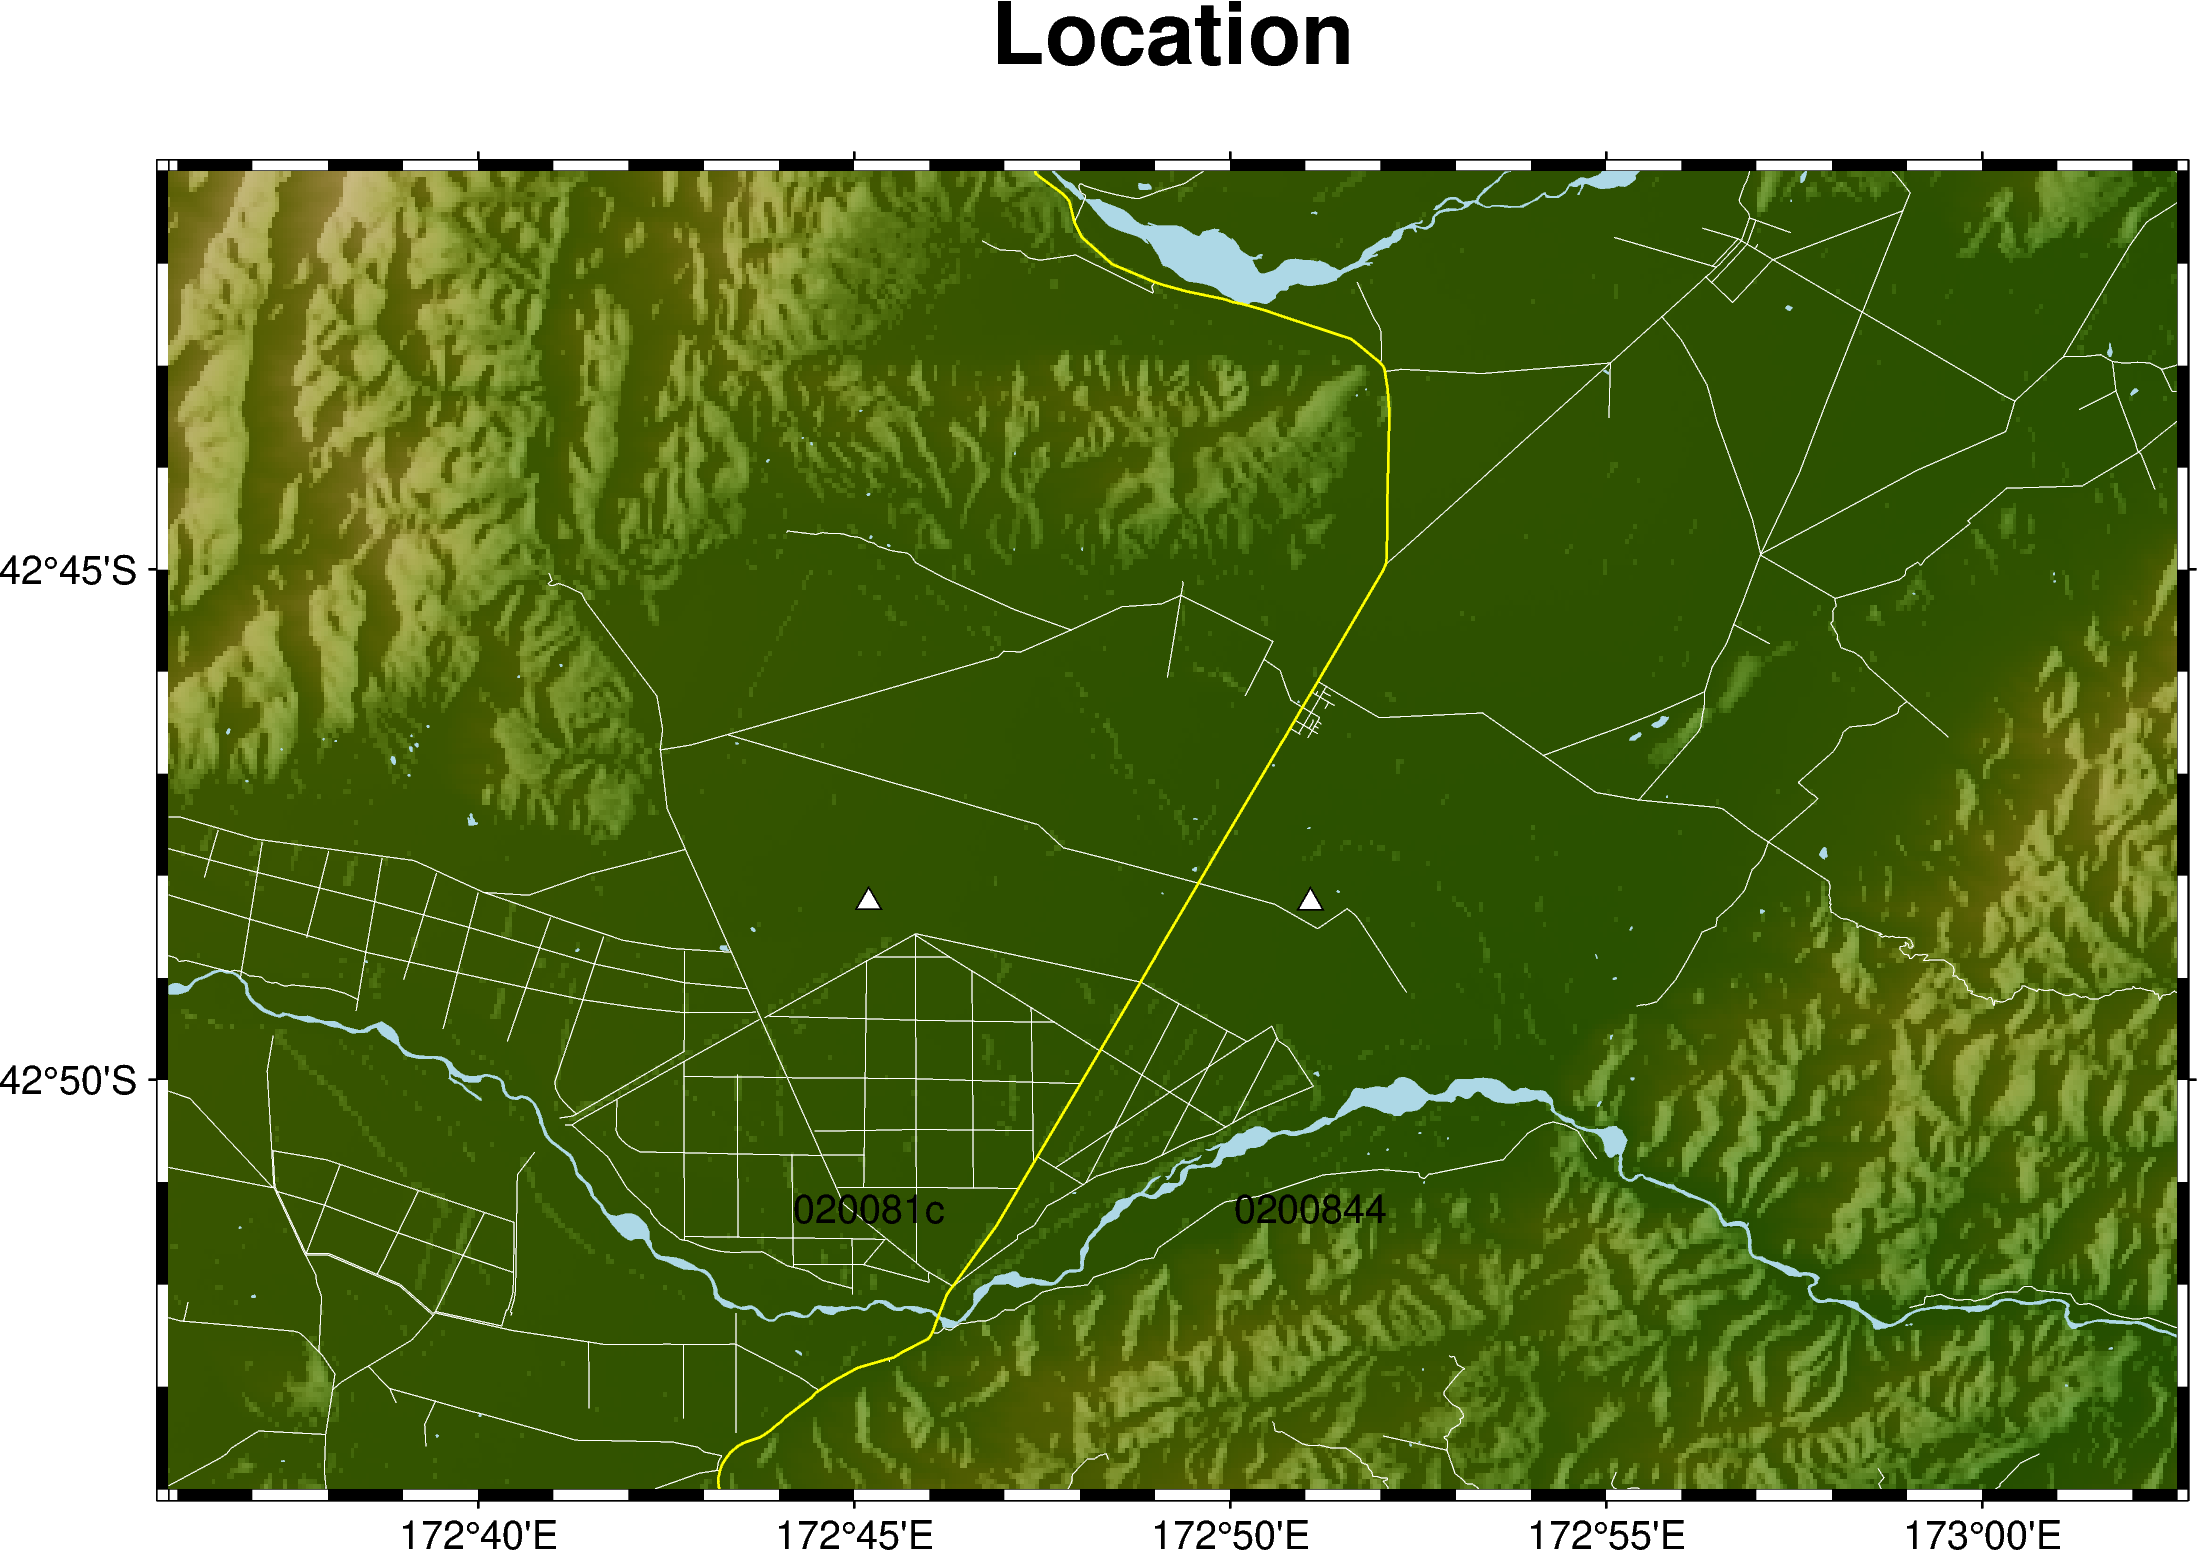

In [17]:
# Generate a loction plot
fig = nn_gmm.gen_region_fig("Location", region, map_data=map_data, plot_kwargs={"topo_cmap": "oleron"})

# Add site + label
fig.plot(x=site_params.loc[cur_site].lon, y=site_params.loc[cur_site].lat, style="t0.25c", color="white", pen="black")
fig.text(text=cur_site, x=site_params.loc[cur_site].lon, y=site_params.loc[cur_site].lat - 0.05)

fig.plot(x=site_params.loc[cur_neighbour].lon, y=site_params.loc[cur_neighbour].lat, style="t0.25c", color="white", pen="black")
fig.text(text=cur_neighbour, x=site_params.loc[cur_neighbour].lon, y=site_params.loc[cur_neighbour].lat - 0.05)

fig.show()

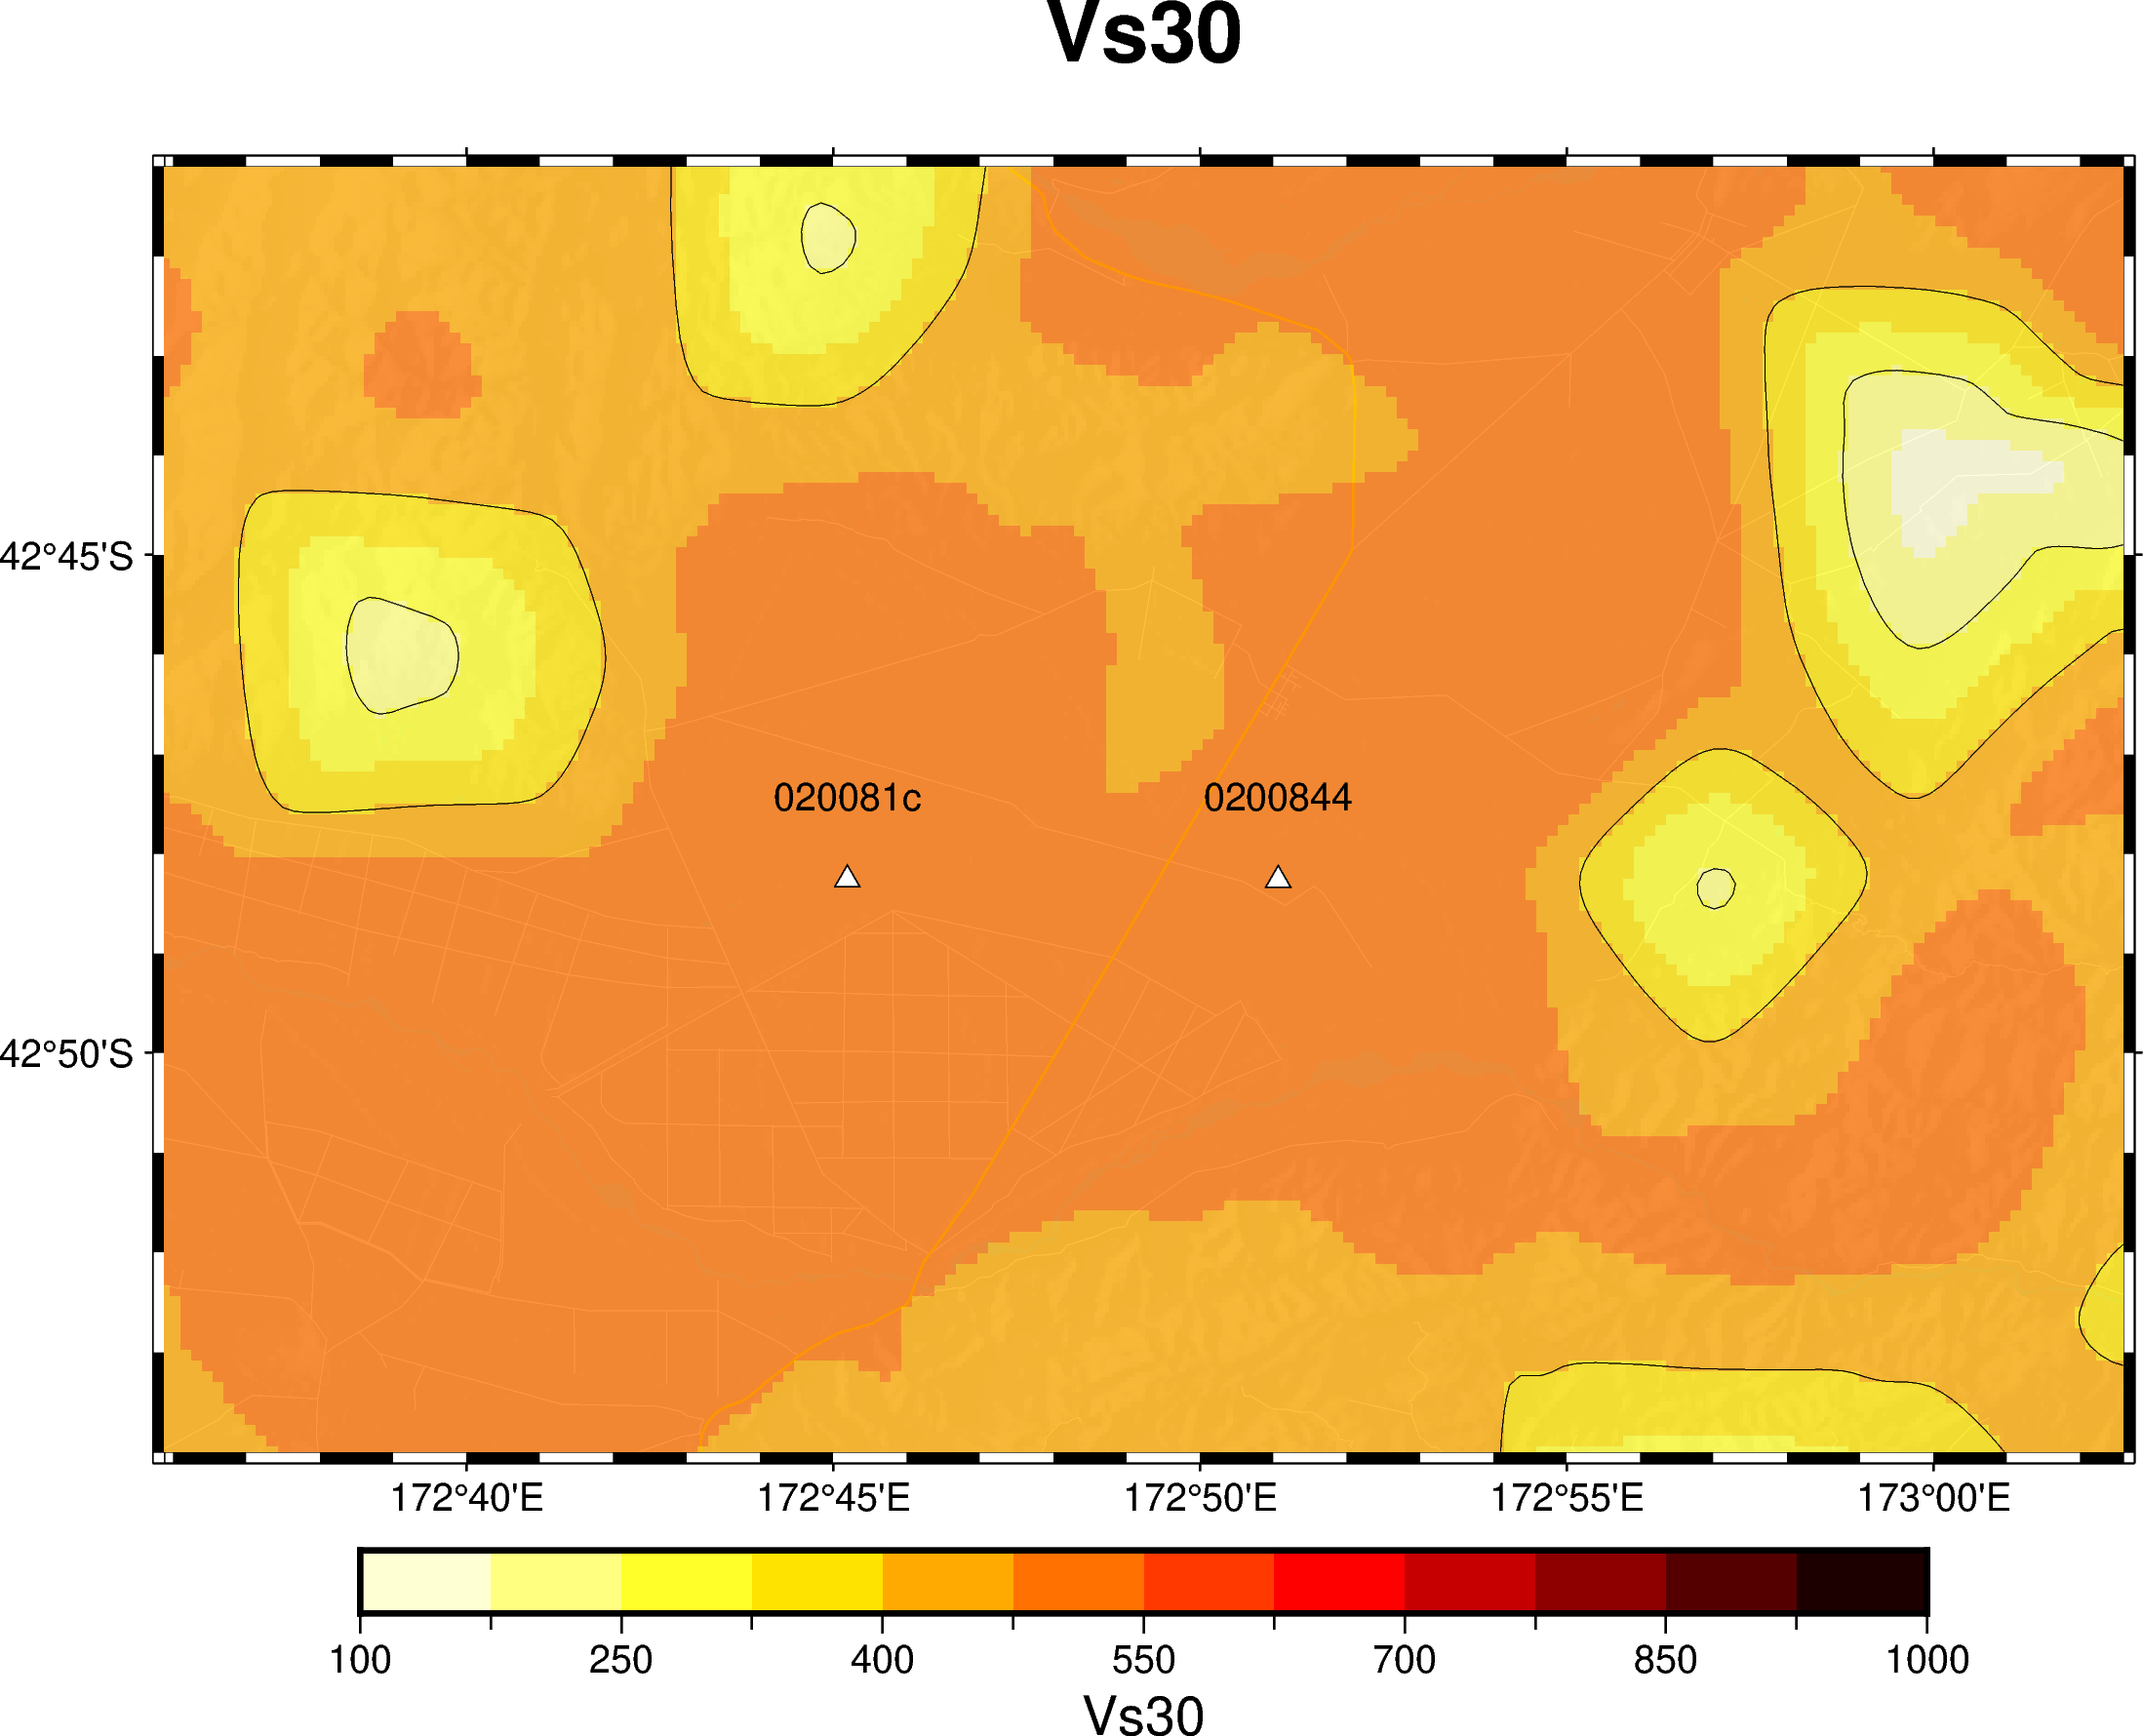

In [18]:
# Vs30 map
fig = nn_gmm.gen_region_fig("Vs30", region, map_data=map_data)

grid = nn_gmm.create_grid(site_params, "vs30", region=region)
nn_gmm.plot_grid(fig, grid, "hot", (100, 1000, 900 / 12),
                 ("white", "black"), "Vs30", transparency=25, reverse_cmap=True)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.790441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.790434)

fig.show()

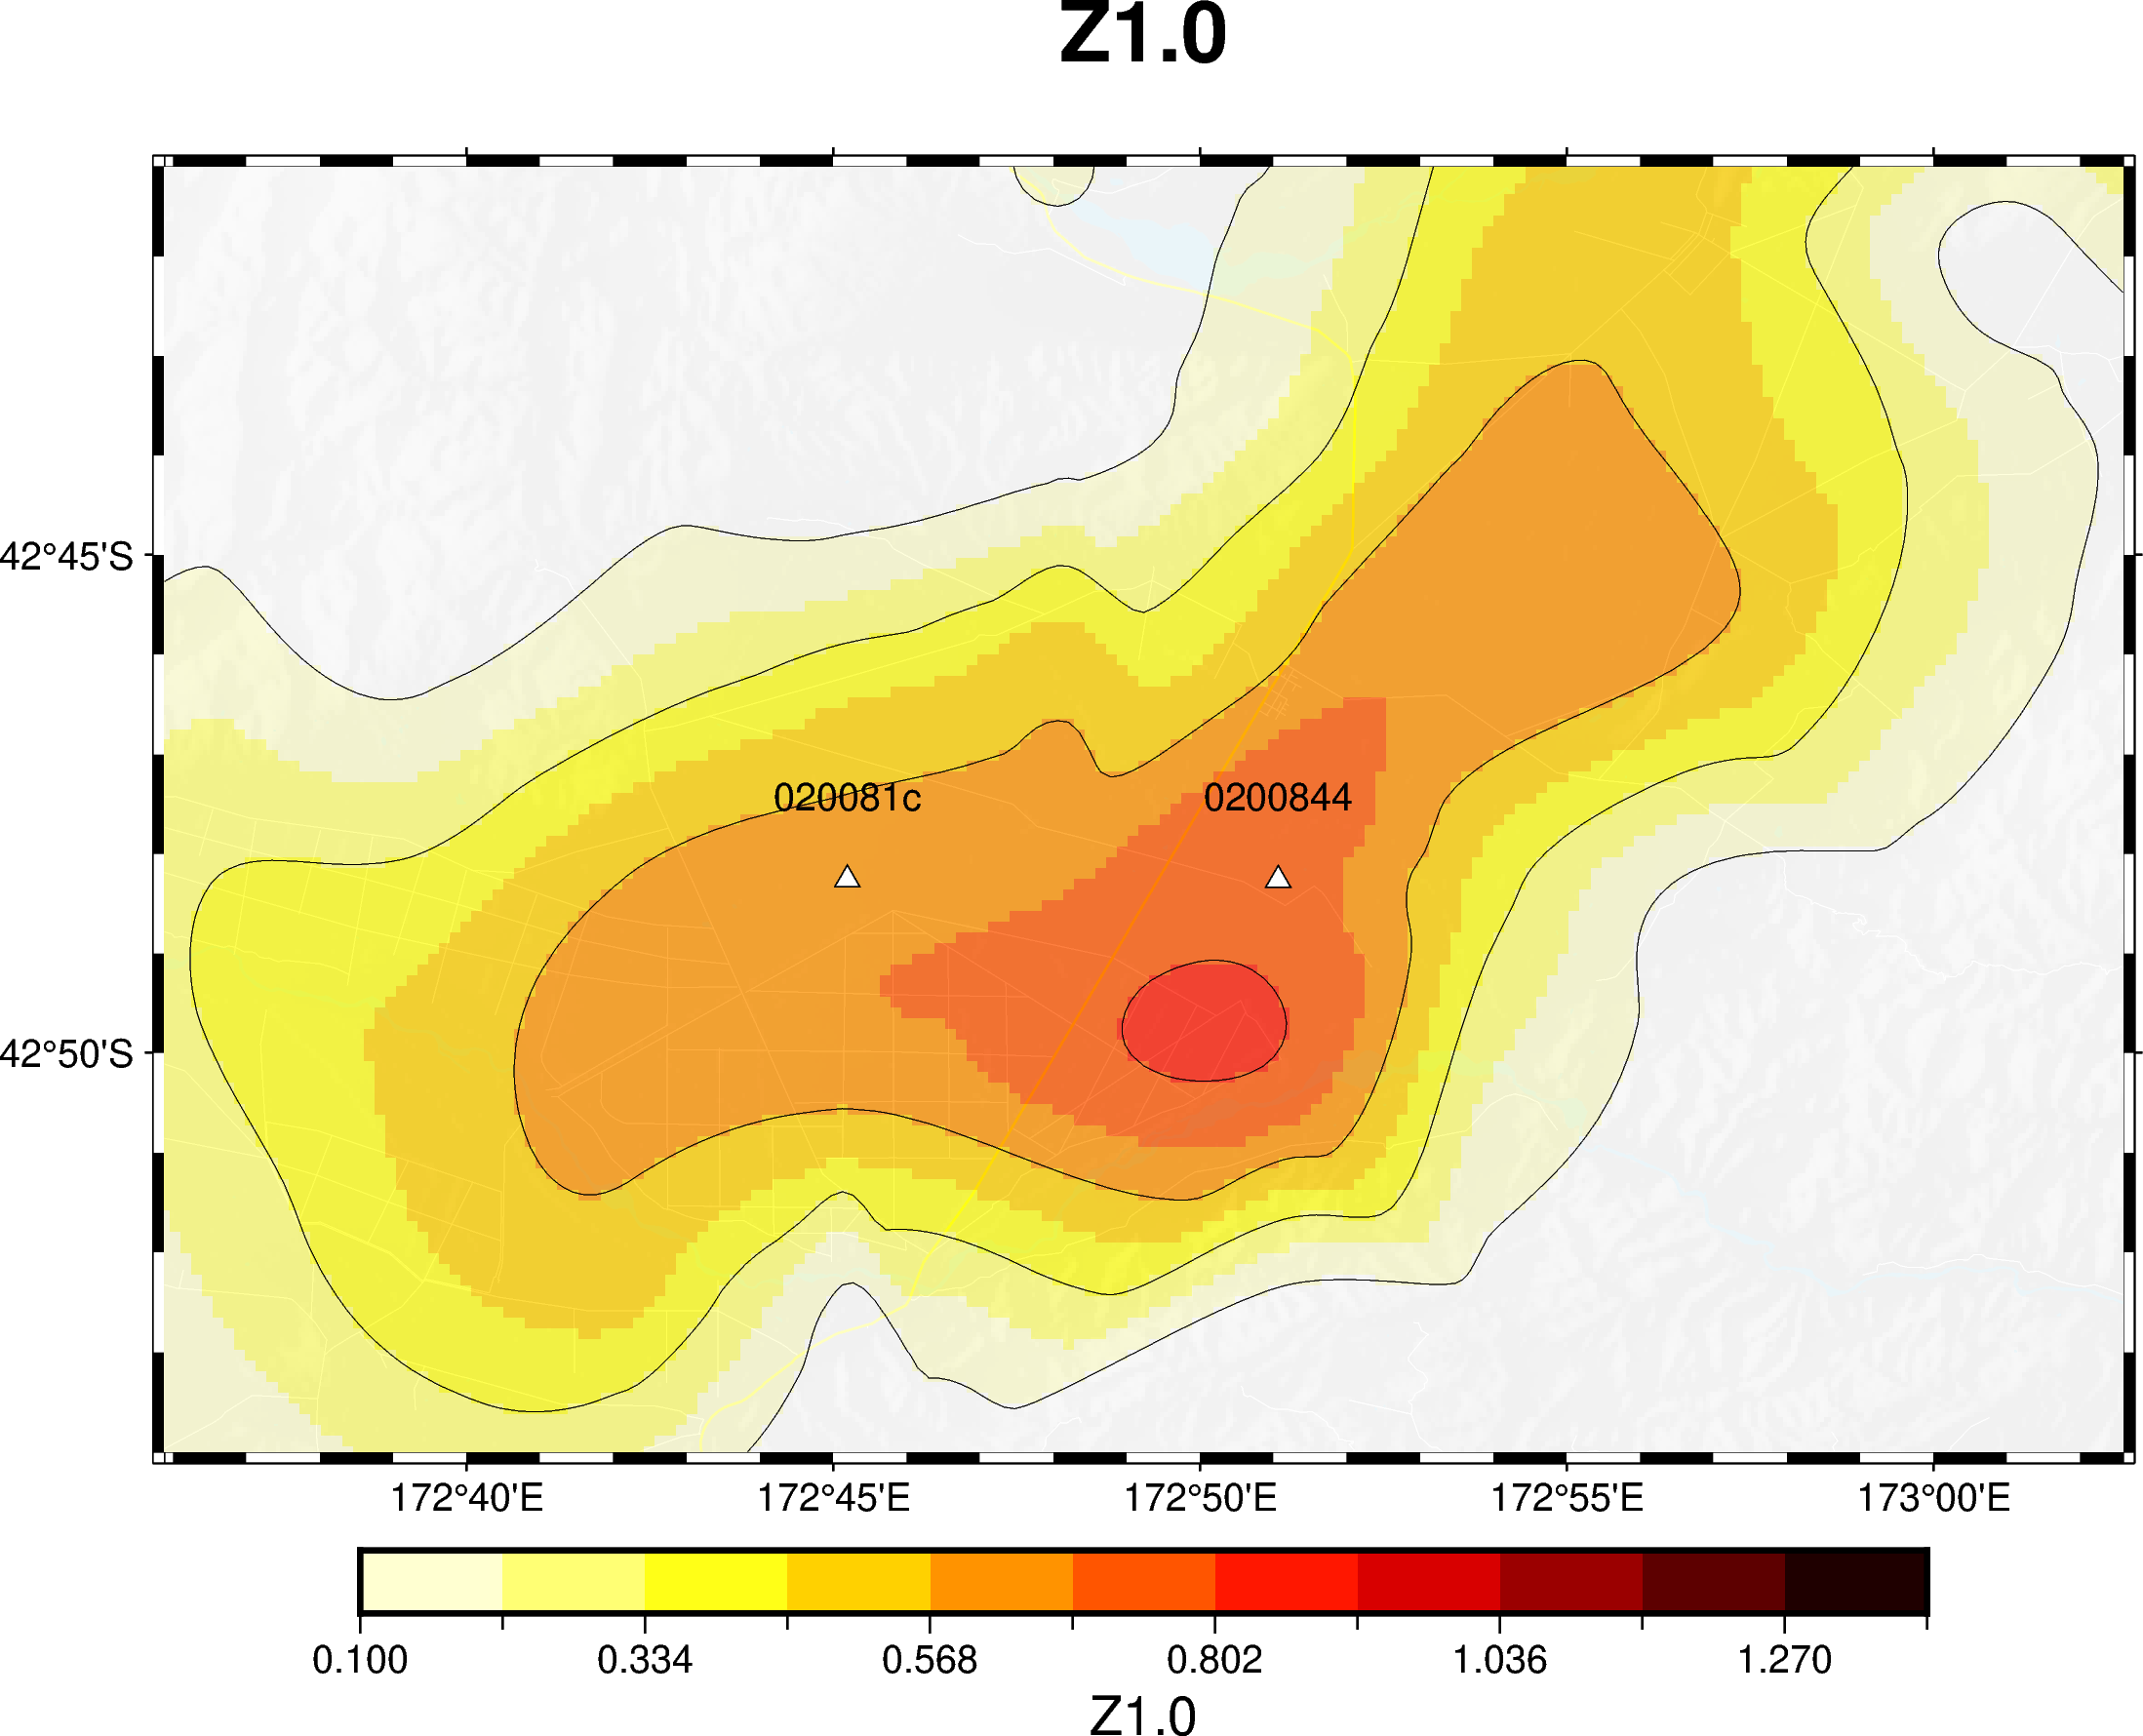

In [19]:
# Z1.0 map
fig = nn_gmm.gen_region_fig("Z1.0", region, map_data=map_data)

grid = nn_gmm.create_grid(site_params, "z1p0", region=region)
nn_gmm.plot_grid(fig, grid, "hot", (0.1, 1.5, np.round((1.5 - 0.1) / 12, 3)),
                 ("white", "black"), "Z1.0", transparency=25, reverse_cmap=True)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.790441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.790434)

fig.show()

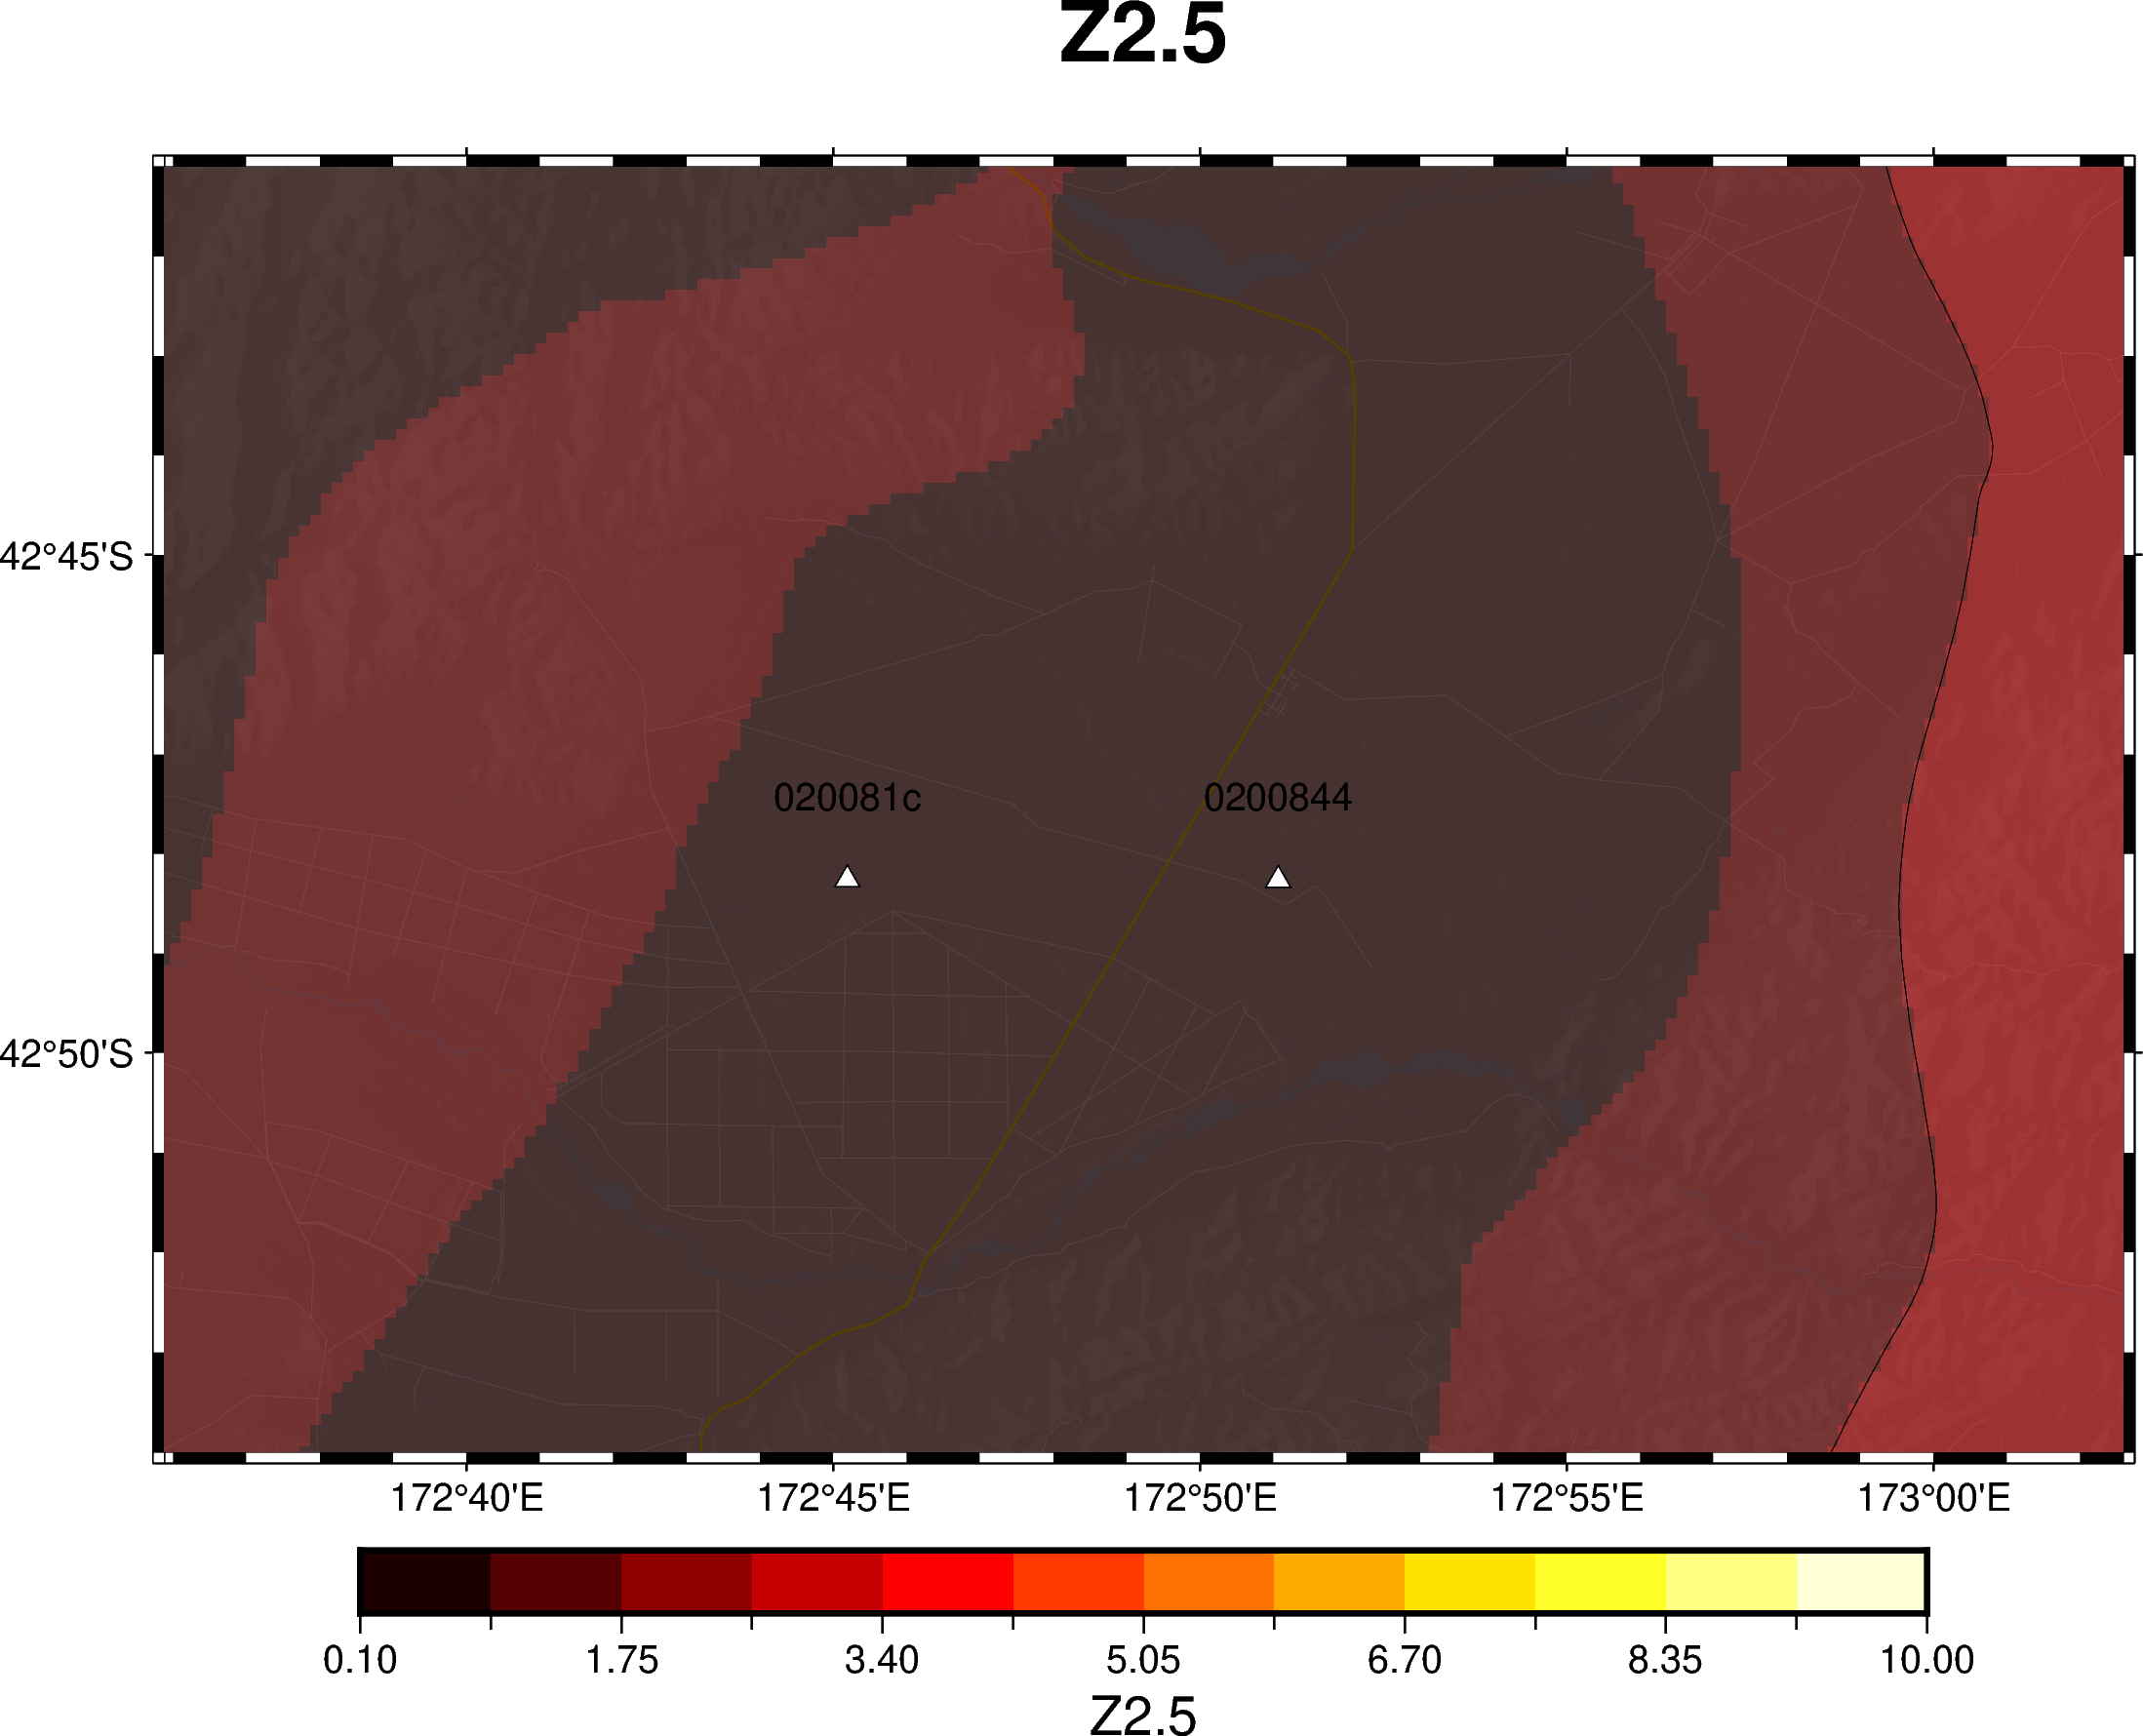

In [20]:
# Z2.5 map
fig = nn_gmm.gen_region_fig("Z2.5", region, map_data=map_data)

grid = nn_gmm.create_grid(site_params, "z2p5", region=region)
nn_gmm.plot_grid(fig, grid, "hot", (0.1, 10.0, (10.0 - 0.1) / 12),
                 ("white", "black"), "Z2.5", transparency=25)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.790441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.790434)


fig.show()

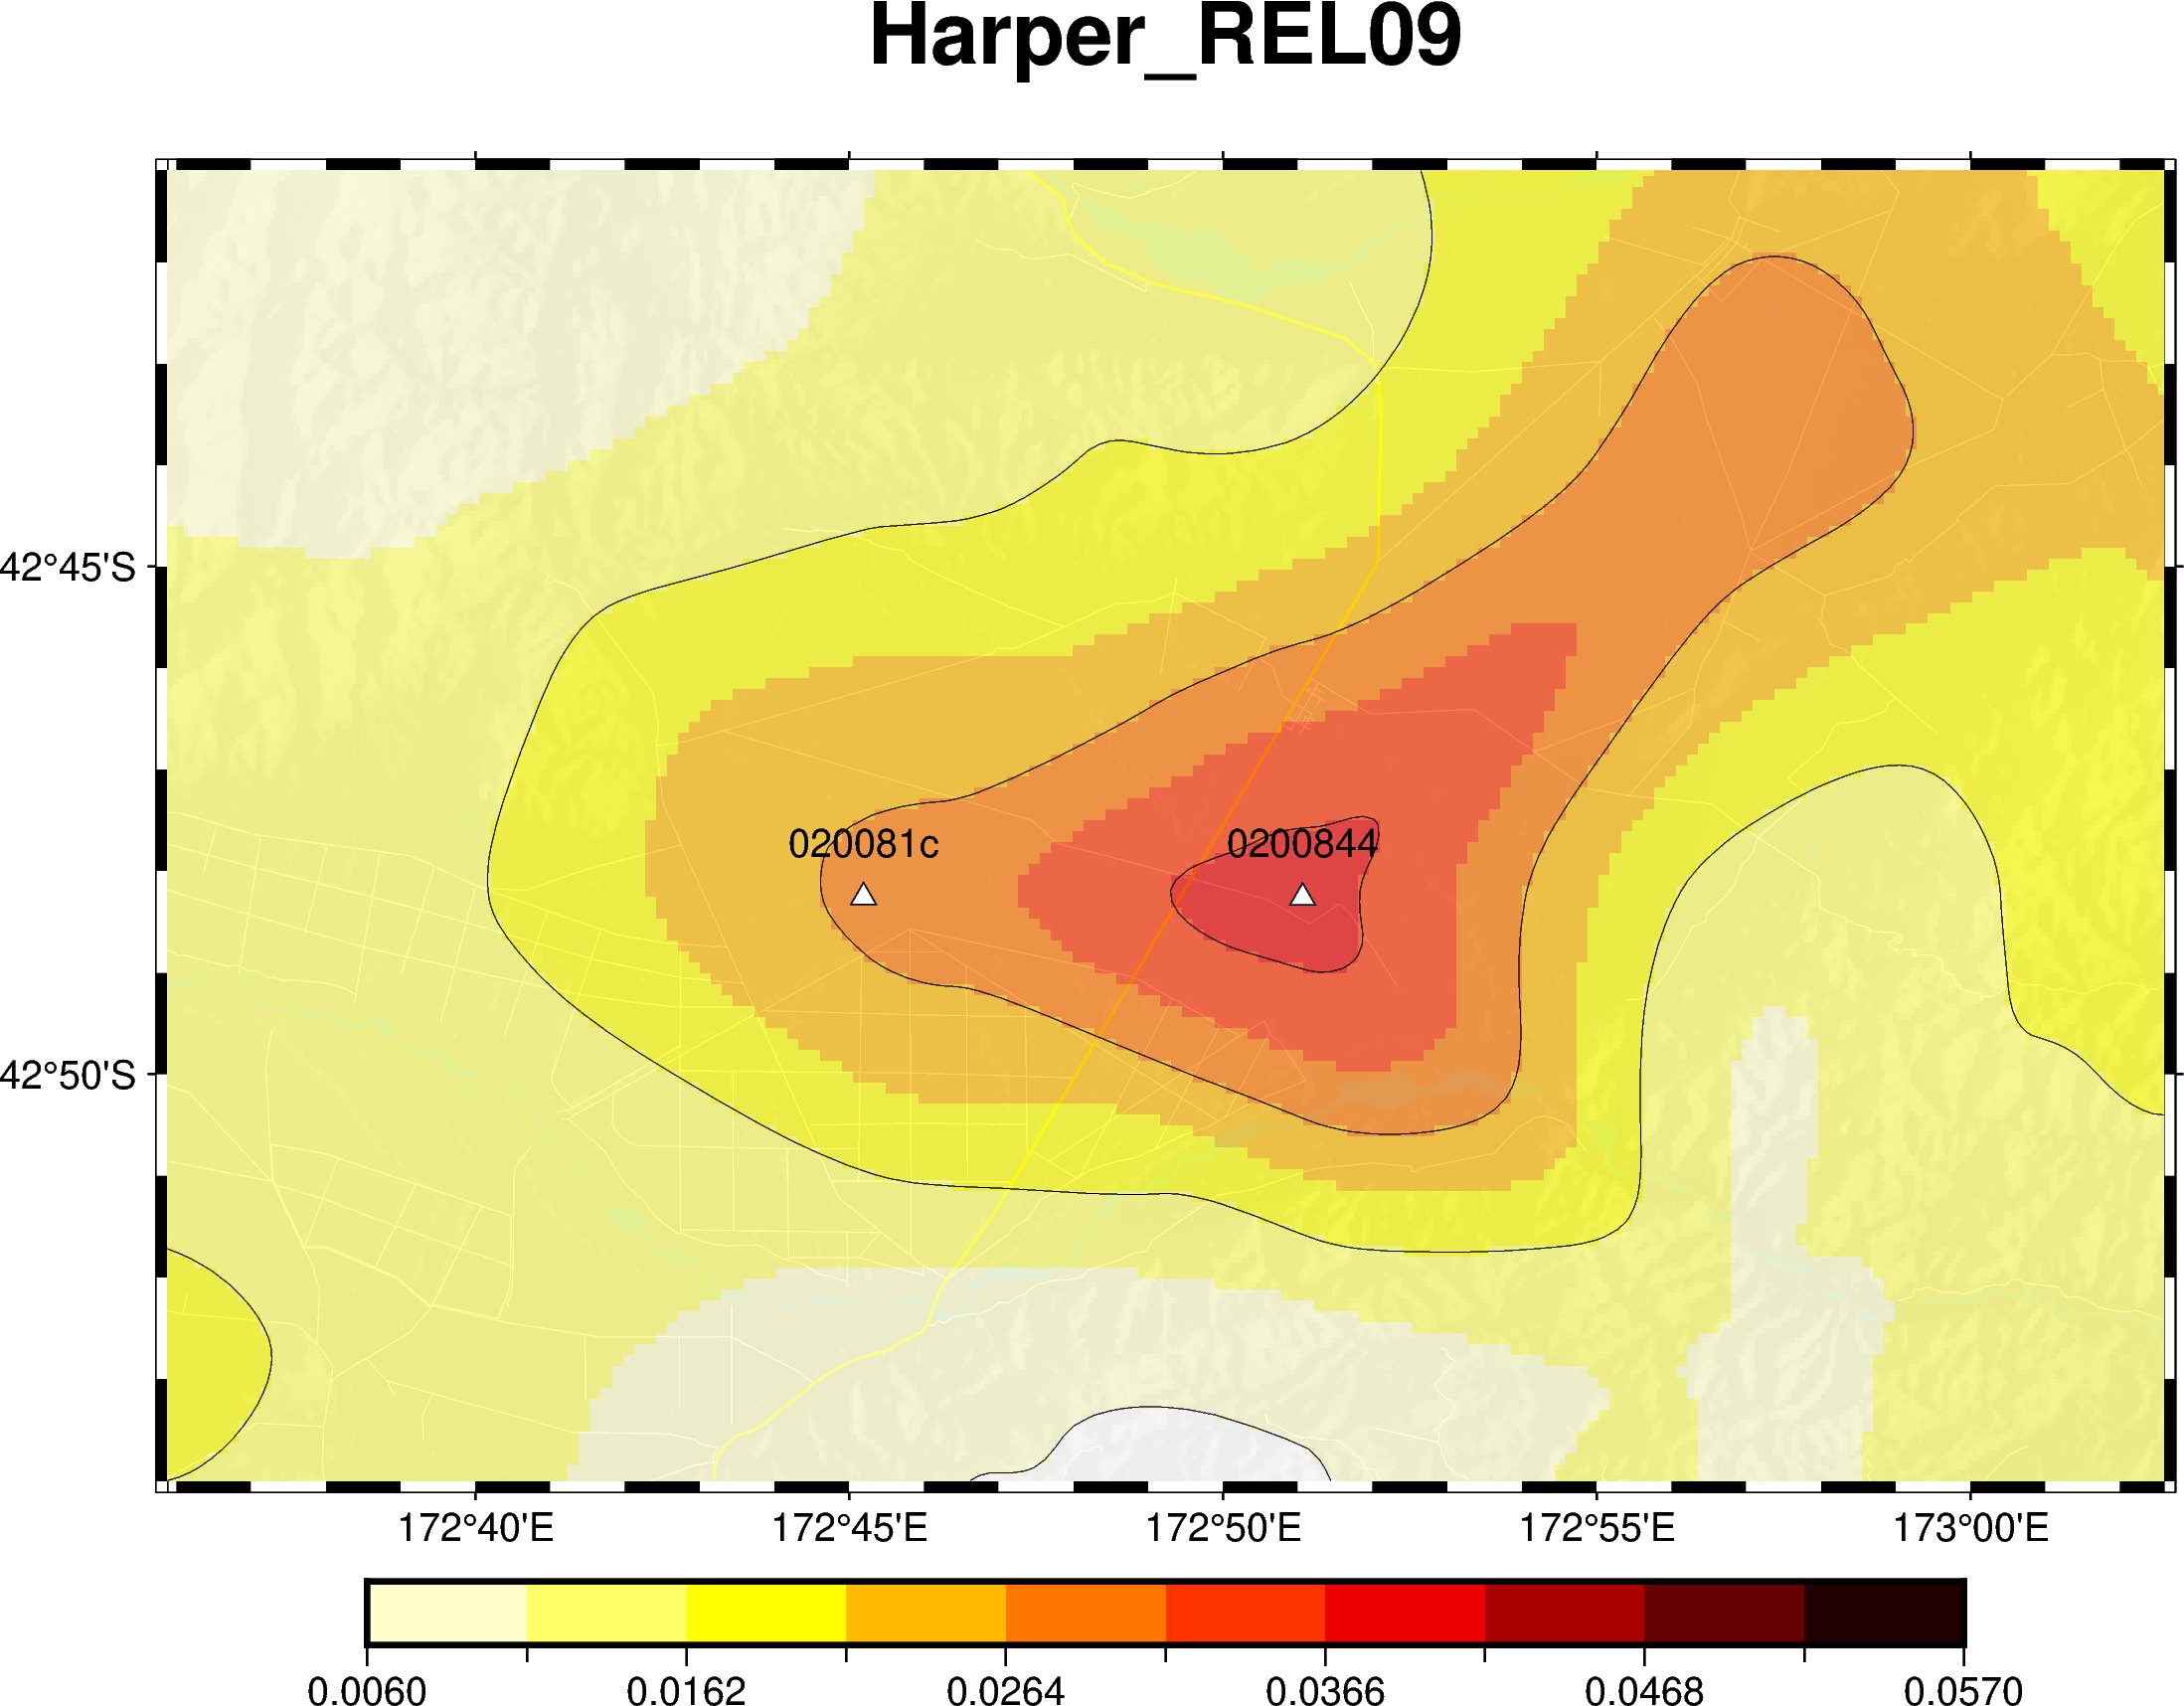

0200844: 0.037962597
020081c: 0.027137158


In [21]:
cur_realisation = "Harper_REL09"
fig = nn_gmm.im_plot(data_df.loc[data_df.realisation == cur_realisation], "pSA_3.0", cur_realisation, map_data_ffp, region=region)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.795441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.795434)

fig.show()

print(f"{cur_site}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_site}", "pSA_3.0"]))
print(f"{cur_neighbour}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_neighbour}", "pSA_3.0"]))

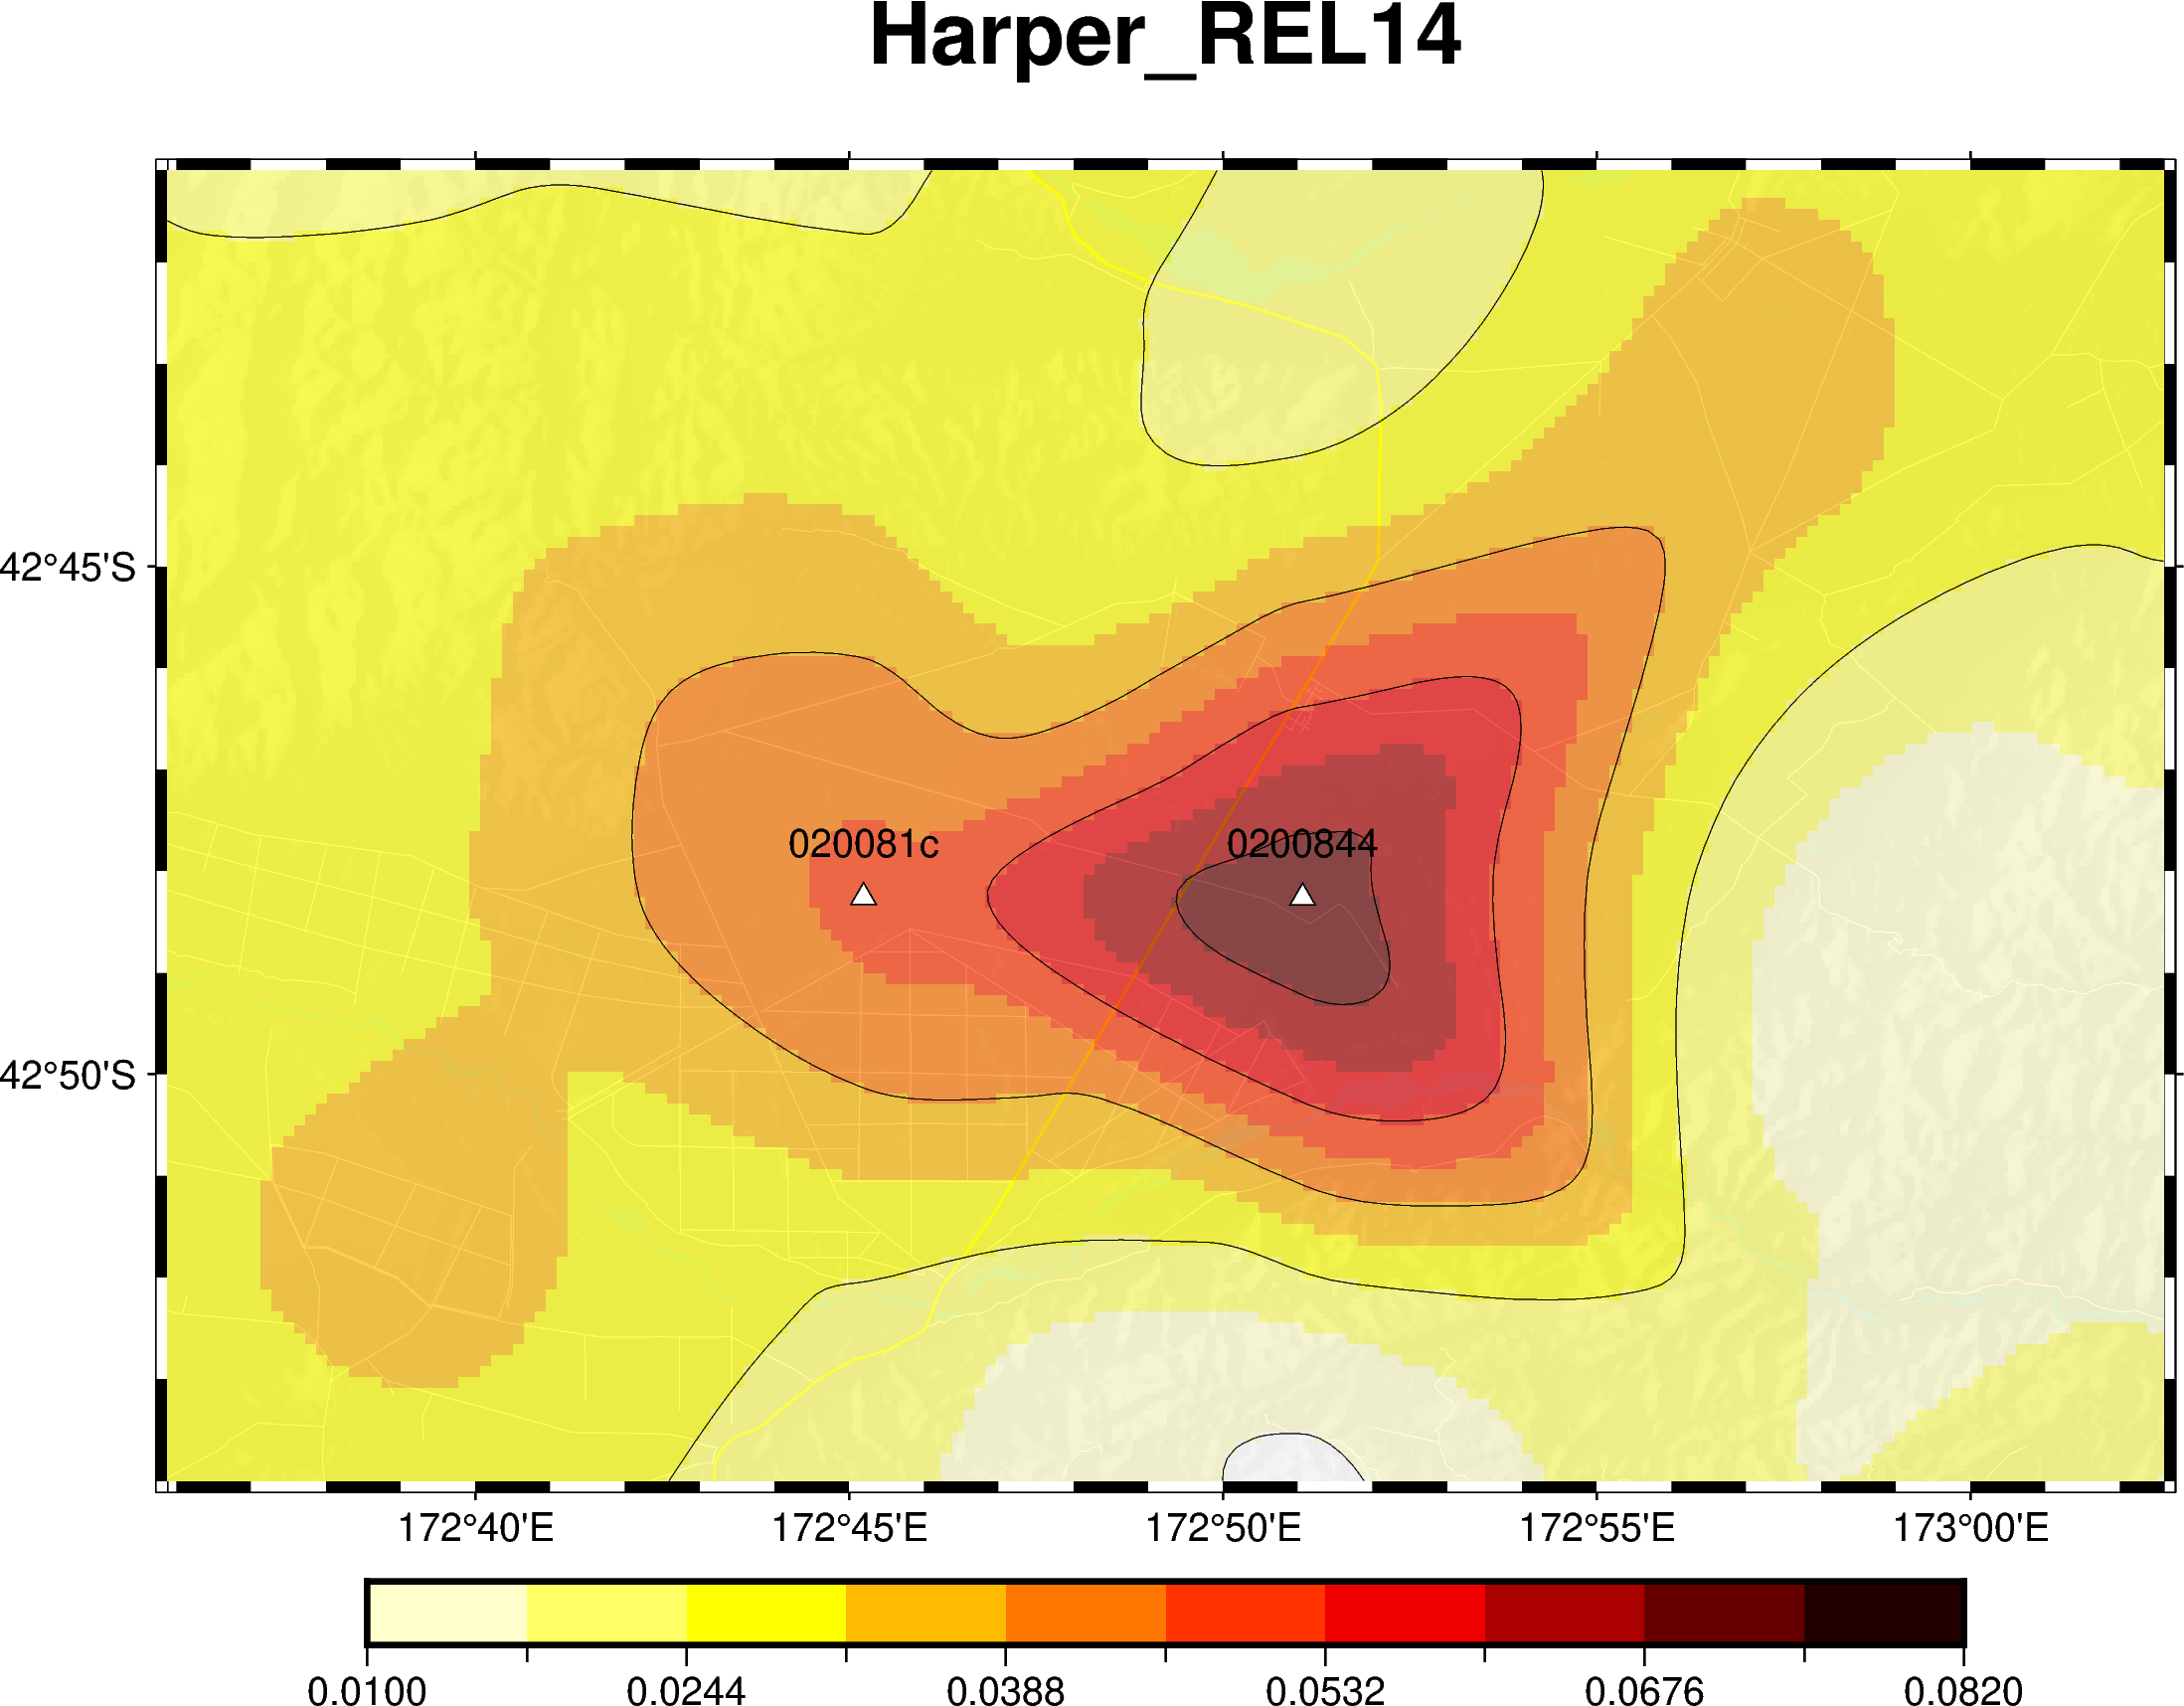

0200844: 0.071191445
020081c: 0.047208697


In [22]:
cur_realisation = "Harper_REL14"
fig = nn_gmm.im_plot(data_df.loc[data_df.realisation == cur_realisation], "pSA_3.0", cur_realisation, map_data_ffp, region=region)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.795441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.795434)

fig.show()

print(f"{cur_site}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_site}", "pSA_3.0"]))
print(f"{cur_neighbour}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_neighbour}", "pSA_3.0"]))

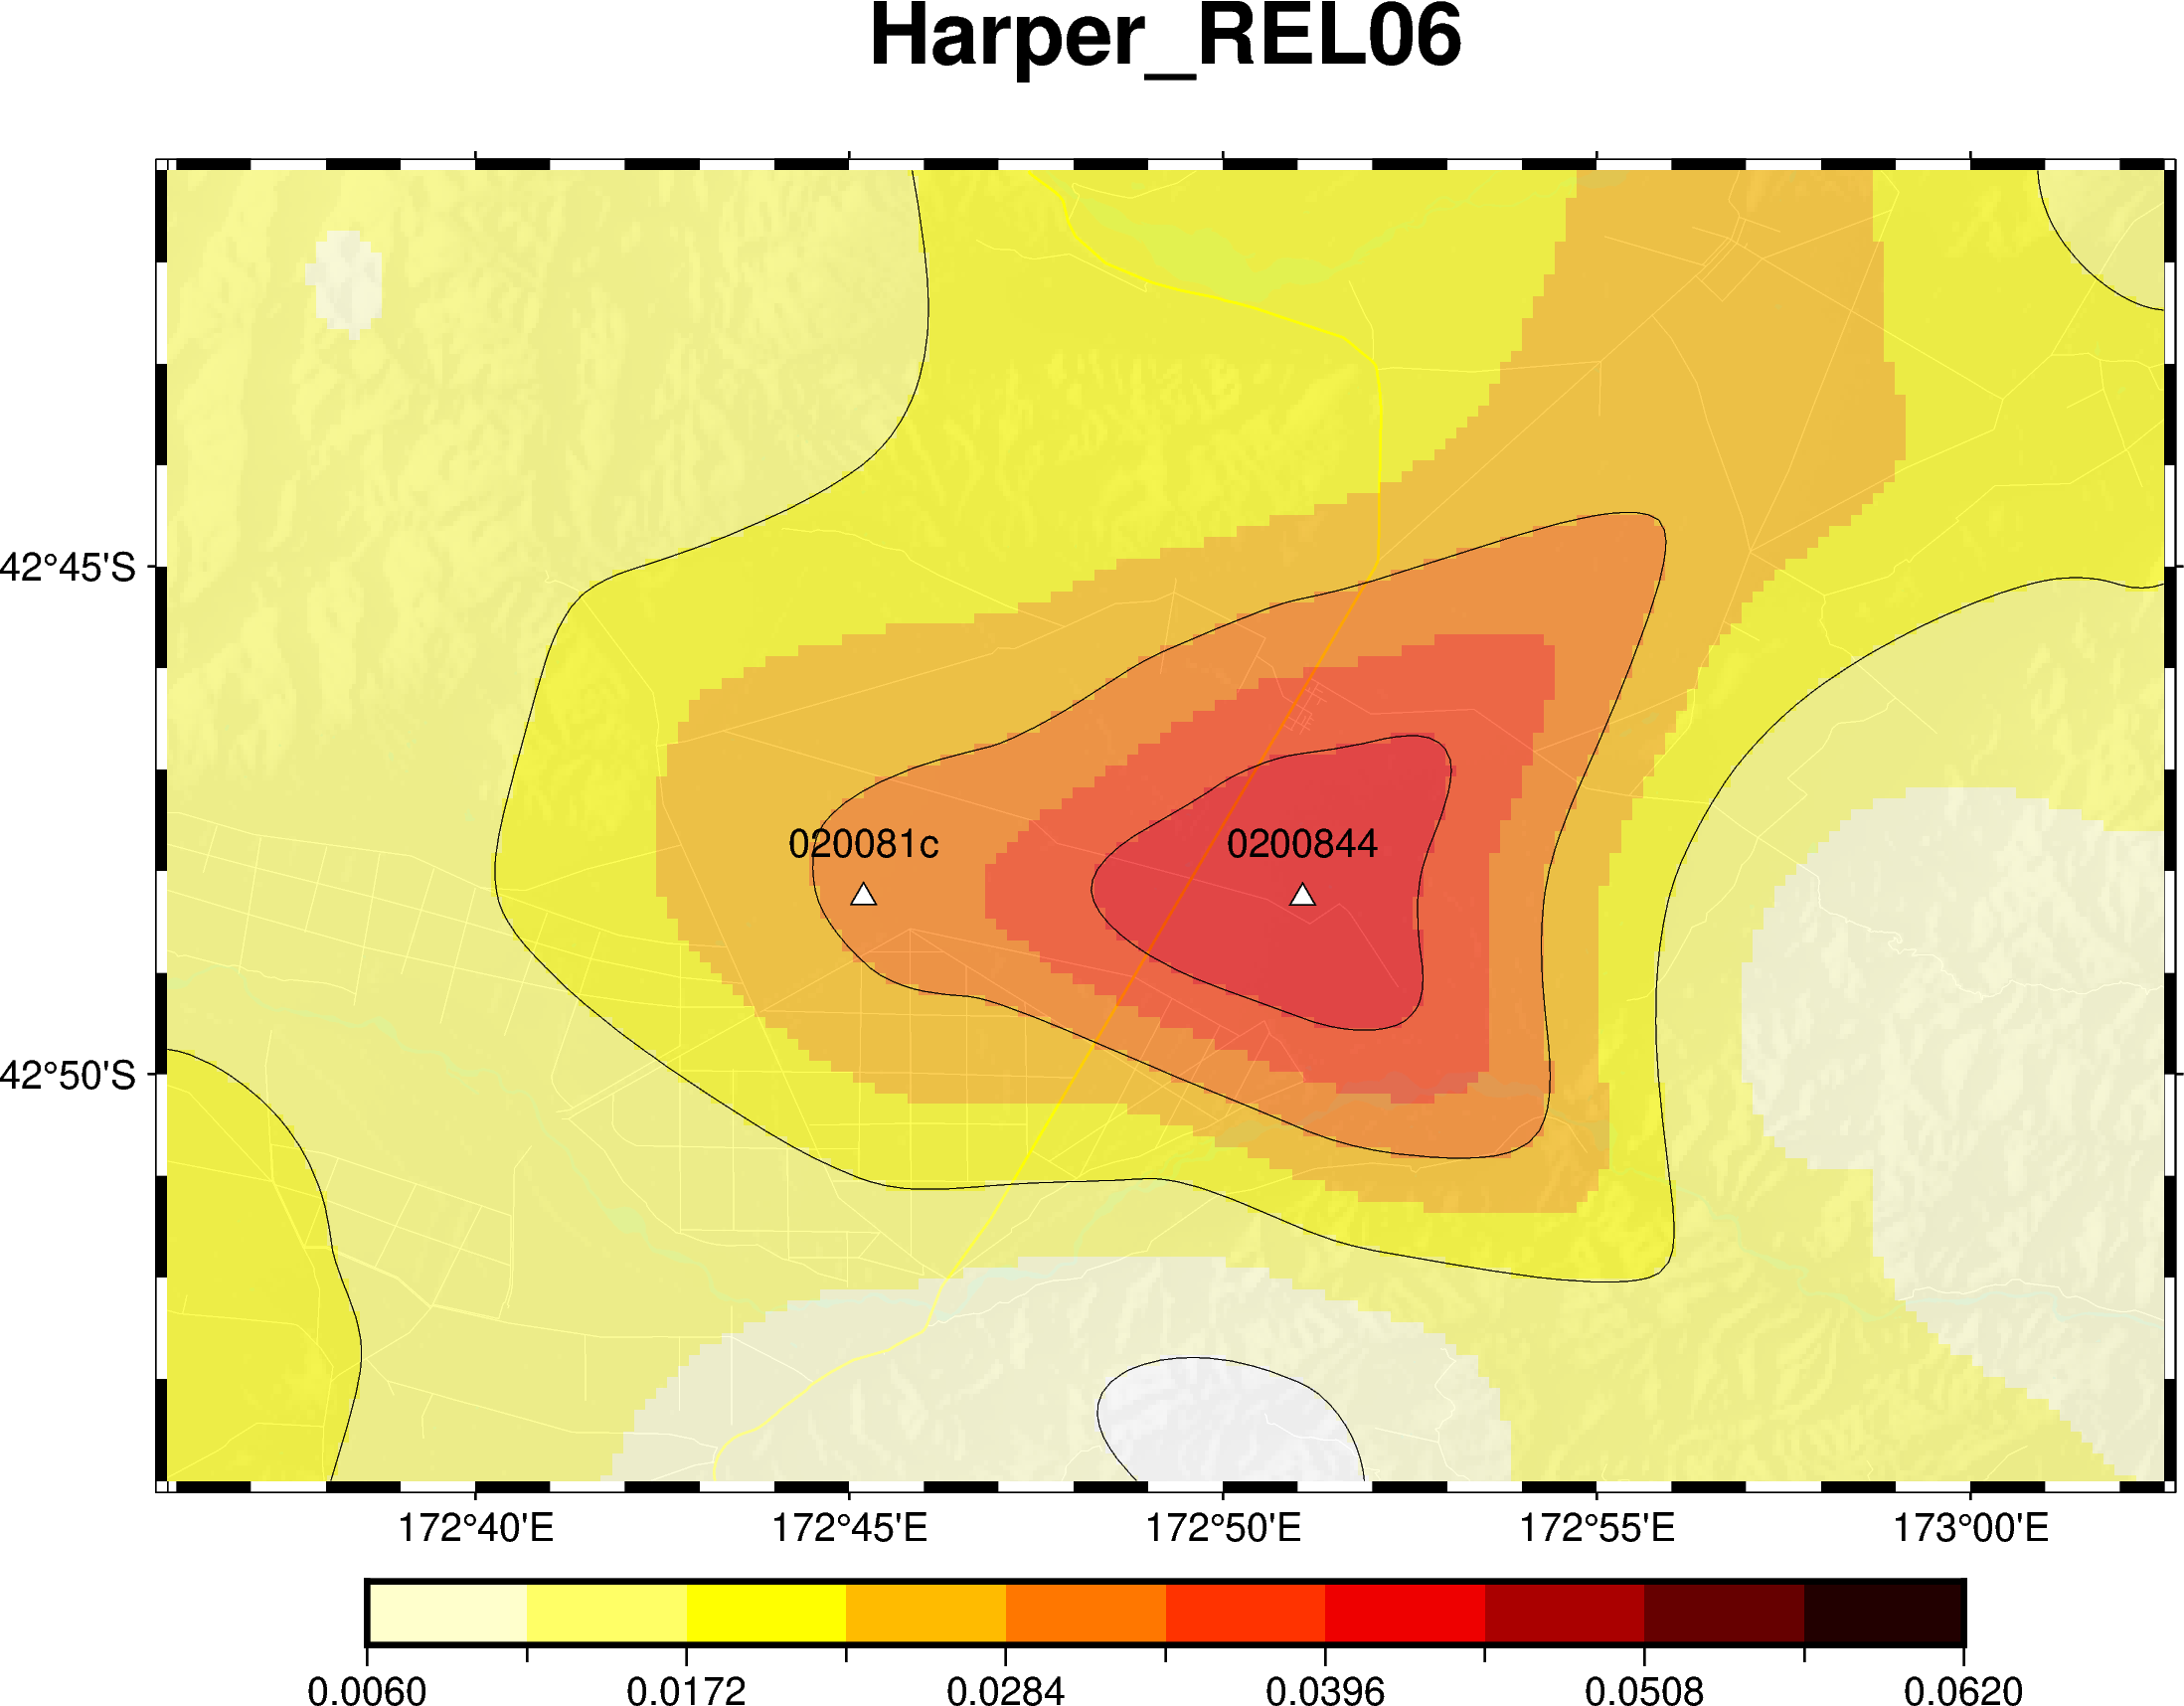

0200844: 0.04489255
020081c: 0.029595604


In [23]:
cur_realisation = "Harper_REL06"
fig = nn_gmm.im_plot(data_df.loc[data_df.realisation == cur_realisation], "pSA_3.0", cur_realisation, map_data_ffp, region=region)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.795441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.795434)

fig.show()

print(f"{cur_site}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_site}", "pSA_3.0"]))
print(f"{cur_neighbour}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_neighbour}", "pSA_3.0"]))

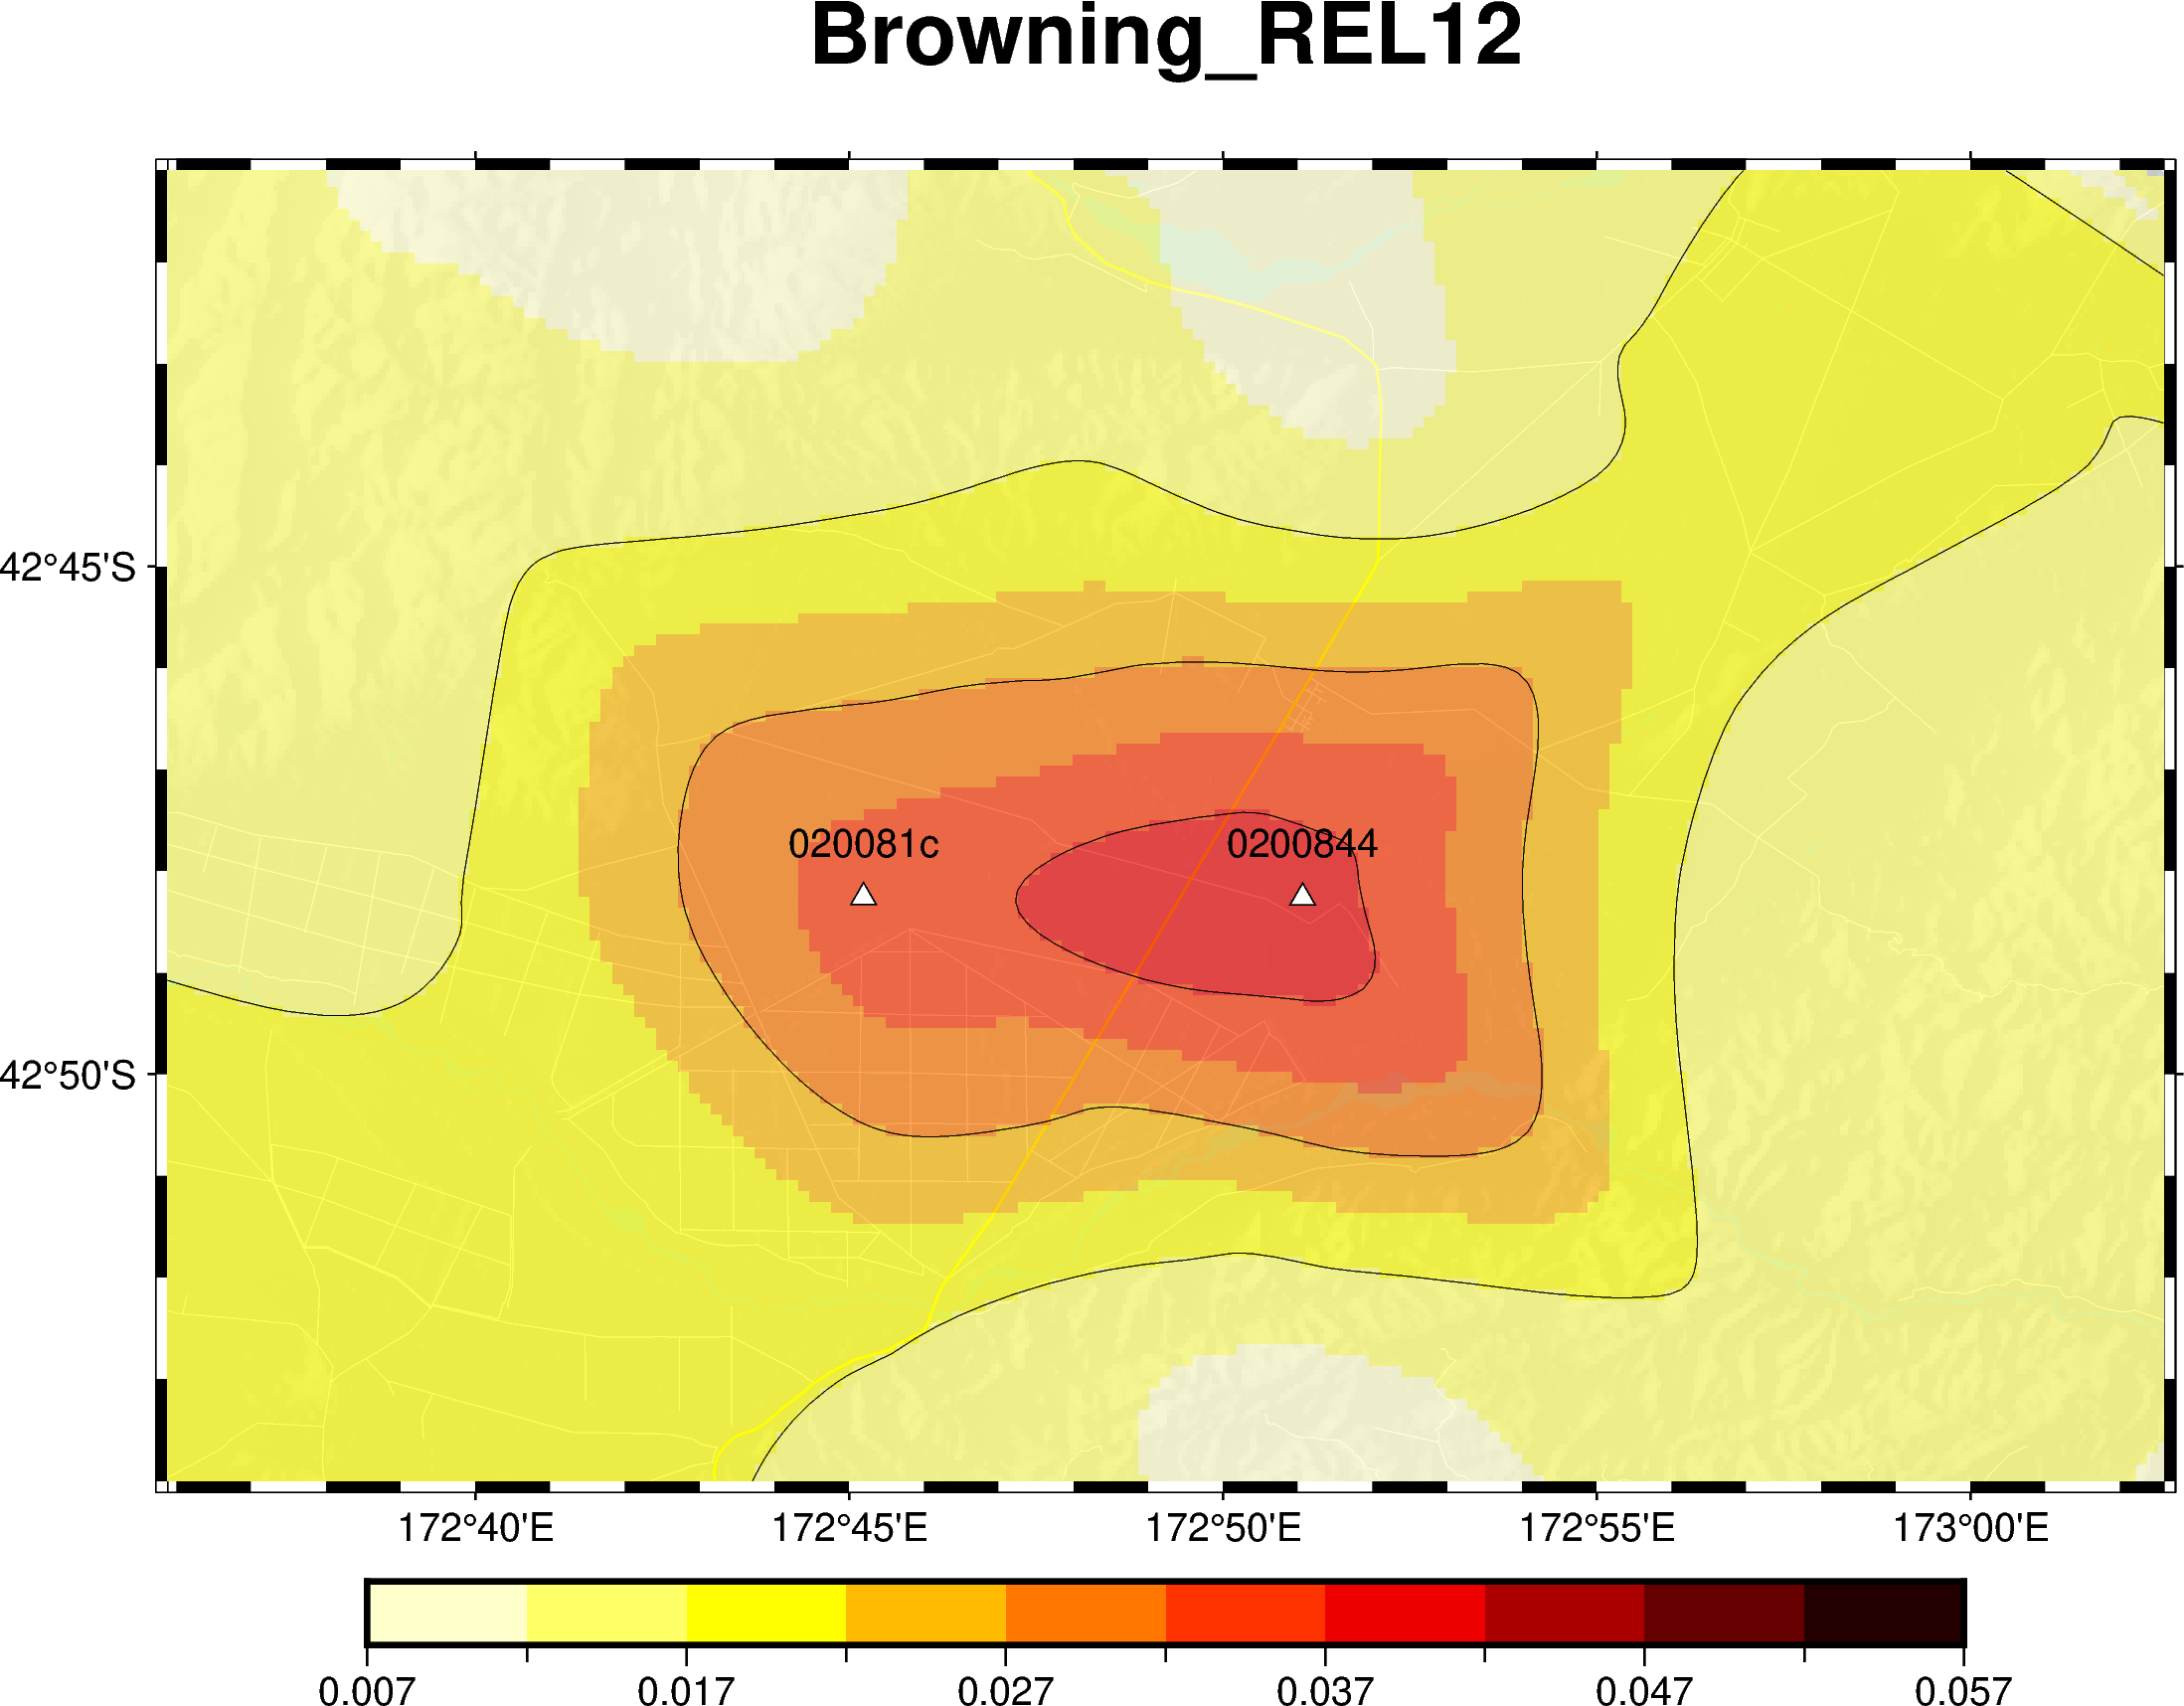

0200844: 0.039073884
020081c: 0.033679802


In [24]:
cur_realisation = "Browning_REL12"
fig = nn_gmm.im_plot(data_df.loc[data_df.realisation == cur_realisation], "pSA_3.0", cur_realisation, map_data_ffp, region=region)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.795441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.795434)

fig.show()

print(f"{cur_site}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_site}", "pSA_3.0"]))
print(f"{cur_neighbour}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_neighbour}", "pSA_3.0"]))

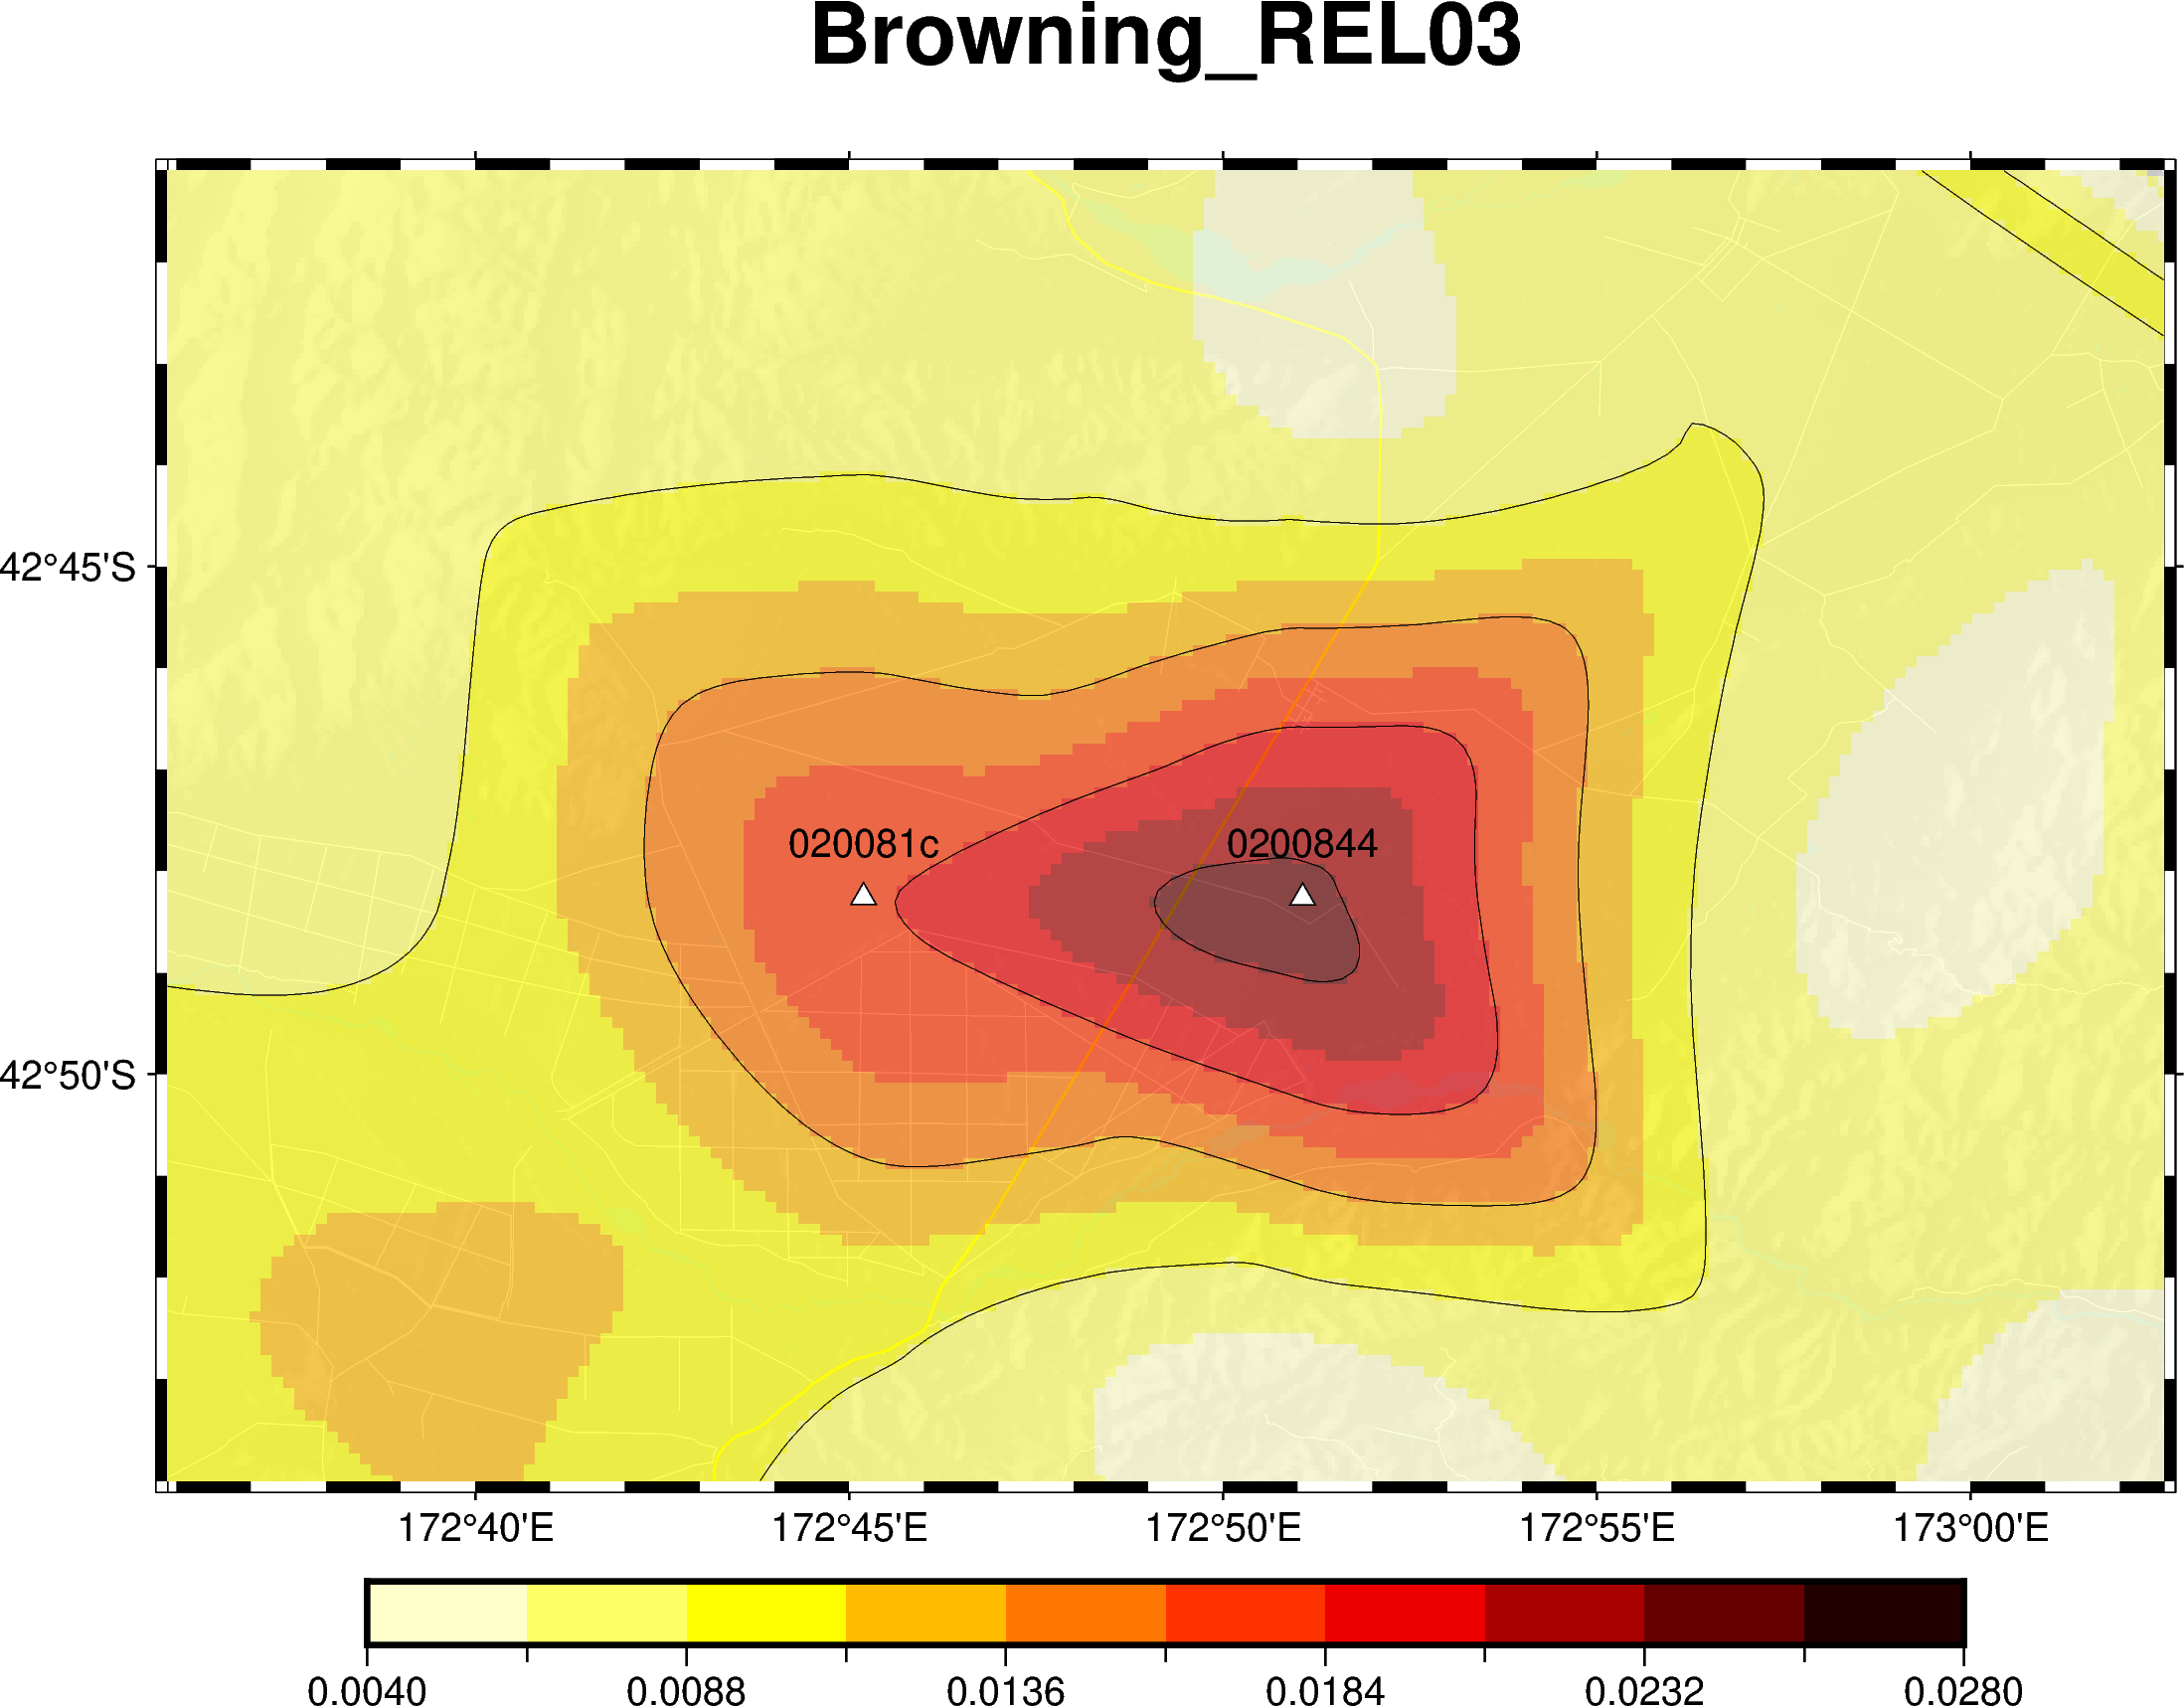

0200844: 0.023806894
020081c: 0.01806708


In [25]:
cur_realisation = "Browning_REL03"
fig = nn_gmm.im_plot(data_df.loc[data_df.realisation == cur_realisation], "pSA_3.0", cur_realisation, map_data_ffp, region=region)

# Add site + label
fig.plot(x=172.85104, y=-42.80441, style="t0.25c", color="white", pen="black")
fig.text(text="0200844", x=172.85104, y=-42.795441)

fig.plot(x=172.75314, y=-42.80434, style="t0.25c", color="white", pen="black")
fig.text(text="020081c", x=172.75314, y=-42.795434)

fig.show()

print(f"{cur_site}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_site}", "pSA_3.0"]))
print(f"{cur_neighbour}:", np.exp(data_df.loc[f"{cur_realisation}_{cur_neighbour}", "pSA_3.0"]))

## Distribution of outliers wrt. to IM

In [26]:
data_df

,lat,lon,pSA_3.0,vs30,pSA_3.0_est,event,site,res,squared_res,realisation
2016p871889_2016p871889_0200859,-41.510830,172.947968,-5.134186,455.000000,-8.412897,2016p871889_2016p871889_0200859,0200859,3.278711e+00,1.074994e+01,2016p871889_2016p871889
2016p859524_2016p859524_HORC,-43.539600,171.959900,-3.514093,521.475037,-6.782937,2016p859524_2016p859524_HORC,HORC,3.268843e+00,1.068534e+01,2016p859524_2016p859524
Inangahua_REL29_MGCS,-41.507702,173.944397,-1.457009,455.000000,-4.691531,Inangahua,MGCS,3.234522e+00,1.046213e+01,Inangahua_REL29
2016p859524_2016p859524_02006c7,-43.519230,171.959457,-3.507386,505.186035,-6.734549,2016p859524_2016p859524_02006c7,02006c7,3.227162e+00,1.041458e+01,2016p859524_2016p859524
Inangahua_REL29_020099b,-41.506451,173.907578,-1.340581,305.083984,-4.507848,Inangahua,020099b,3.167268e+00,1.003159e+01,Inangahua_REL29
...,...,...,...,...,...,...,...,...,...,...
Cust_REL08_FJDS,-43.389099,170.184204,-5.519011,335.279510,-5.519011,Cust,FJDS,-9.536743e-07,9.094947e-13,Cust_REL08
SFiordMg13_REL06_0200065,-45.686218,167.309525,-4.787869,690.974365,-4.787869,SFiordMg13,0200065,-4.768372e-07,2.273737e-13,SFiordMg13_REL06
TaieriR_REL04_0200282,-44.467129,169.129944,-4.609304,500.000000,-4.609303,TaieriR,0200282,-4.768372e-07,2.273737e-13,TaieriR_REL04
NorthCant4_REL12_020081a,-42.660599,172.753464,-5.483402,455.000000,-5.483401,NorthCant4,020081a,-4.768372e-07,2.273737e-13,NorthCant4_REL12


In [27]:
im_values = np.exp(data_df["pSA_3.0"].values)

Text(0.5, 1.0, 'Distribution of worst 1% of outliers (pSA_3.0)')

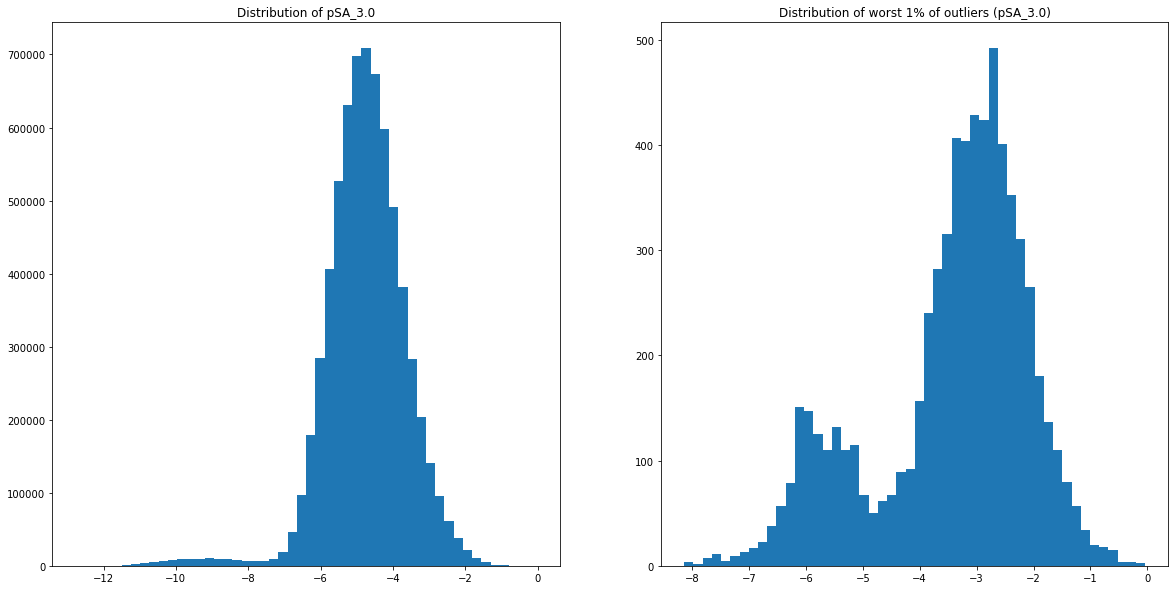

In [28]:
fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(1, 2, 1)
# ax.hist(im_values[im_values < 0.2], bins=50);
ax.hist(data_df.loc[:, "pSA_3.0"].values, bins=50);
ax.set_title("Distribution of pSA_3.0")

ax = fig.add_subplot(1, 2, 2)
ax.hist(data_df.loc[mask, "pSA_3.0"].values, bins=50);
ax.set_title("Distribution of worst 1% of outliers (pSA_3.0)")

In [29]:
# bins = np.arange(0.0, 0.2, 0.01)
# bin_ind = np.digitize(im_values, bins)

bins = np.arange(-12.0, np.log(0.2), 0.1)
bin_ind = np.digitize(data_df["pSA_3.0"], bins)

df = data_df.copy()
df["bin_ix"] = bin_ind
df["abs_res"] = np.abs(df["res"].values)

group_mean = df.loc[:, ["abs_res", "squared_res", "bin_ix"]].groupby("bin_ix").mean()
abs_res_binned = group_mean.abs_res.values
squared_res_binned = group_mean.squared_res.values

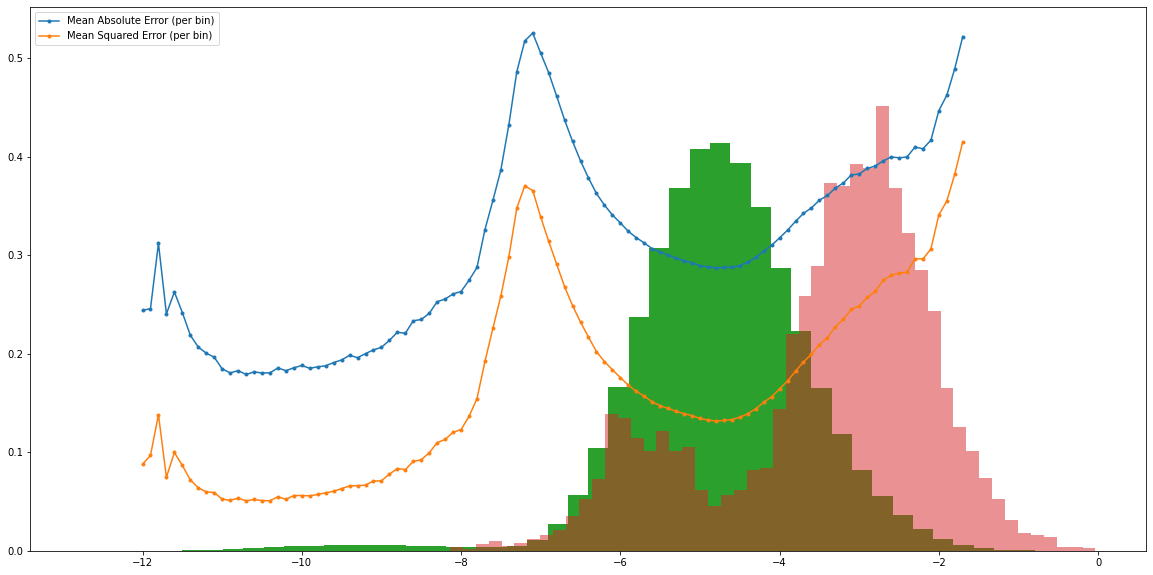

In [30]:
fig = plt.figure(figsize=(20, 10))

plt.plot(bins, abs_res_binned[:-1], marker=".", label="Mean Absolute Error (per bin)")
plt.plot(bins, squared_res_binned[:-1], marker=".", label="Mean Squared Error (per bin)")
plt.hist(data_df.loc[:, "pSA_3.0"].values, bins=50, density=True);
plt.hist(data_df.loc[mask, "pSA_3.0"].values, bins=50, density=True, alpha=0.5);

plt.legend()